In [1]:
import pandas as pd
import numpy as np

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
data=pd.read_csv('Employee_Performance_Dataset.csv')
data.head()

,Employee Number,Age,Gender,Educational Background,Marital Status,Employee Department,Employee Job Role,Business_Travel_Frequency,Distance From Home,Employee Education Level,...,Emp_Relationship_Satisfaction,Total_Work_Experience_In_Years,Training_Times_Last_Year,Emp_Work_Family_Life_Balance,Experience_Years_At_This_Company,Experience_Years_In Current Role,Years_Since_Last_Promotion,Years with Current Manager,Attrition,Performance Rating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [4]:
data.shape

(1200, 28)

In [5]:
data.drop(columns=["Employee Number"], inplace=True)

In [6]:
data.shape

(1200, 27)

In [7]:
# Show all columns
pd.set_option('display.max_columns', None)

In [8]:
data.head(2)

,Age,Gender,Educational Background,Marital Status,Employee Department,Employee Job Role,Business_Travel_Frequency,Distance From Home,Employee Education Level,Employee Environment Satisfaction,Employee Hourly Rate,Employee Job Involvement,Employee Job Level,Employee Job Satisfaction,Num_Companies_Worked,Overtime,Emp_LastSalary_Hike_Percent,Emp_Relationship_Satisfaction,Total_Work_Experience_In_Years,Training_Times_Last_Year,Emp_Work_Family_Life_Balance,Experience_Years_At_This_Company,Experience_Years_In Current Role,Years_Since_Last_Promotion,Years with Current Manager,Attrition,Performance Rating
0,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3


In [9]:
int(data.isna().any(axis=1).sum())

0

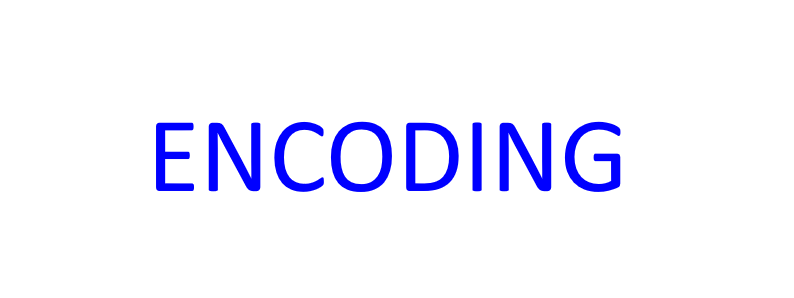

**WAY TOWARDS ENCODING**

In [10]:
non_numeric_cols = data.select_dtypes(exclude=['number']).columns

In [11]:
summary = pd.DataFrame({
    'Column': non_numeric_cols,
    'Category_Count': [data[c].nunique(dropna=True) for c in non_numeric_cols]
})
print(summary)

                      Column  Category_Count
0                     Gender               2
1     Educational Background               6
2             Marital Status               3
3        Employee Department               6
4          Employee Job Role              19
5  Business_Travel_Frequency               3
6                   Overtime               2
7                  Attrition               2


**Action:** The categorical columns having 2 levels are nominal in nature. Encoding them as 0 and 1.

In [12]:
data["Attrition"] = data["Attrition"].map({"No": 0,"Yes": 1})
data["Overtime"] = data["Overtime"].map({"No": 0, "Yes": 1})
data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})

In [13]:
data.shape

(1200, 27)

In [14]:
data.head()

,Age,Gender,Educational Background,Marital Status,Employee Department,Employee Job Role,Business_Travel_Frequency,Distance From Home,Employee Education Level,Employee Environment Satisfaction,Employee Hourly Rate,Employee Job Involvement,Employee Job Level,Employee Job Satisfaction,Num_Companies_Worked,Overtime,Emp_LastSalary_Hike_Percent,Emp_Relationship_Satisfaction,Total_Work_Experience_In_Years,Training_Times_Last_Year,Emp_Work_Family_Life_Balance,Experience_Years_At_This_Company,Experience_Years_In Current Role,Years_Since_Last_Promotion,Years with Current Manager,Attrition,Performance Rating
0,32,0,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,0,12,4,10,2,2,10,7,0,8,0,3
1,47,0,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,0,12,4,20,2,3,7,7,1,7,0,3
2,40,0,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,1,21,3,20,2,3,18,13,1,12,0,4
3,41,0,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,0,15,2,23,2,2,21,6,12,6,0,3
4,60,0,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,0,14,4,10,1,3,2,2,2,2,0,3


In [15]:
non_numeric_cols = data.select_dtypes(exclude=['number']).columns

In [16]:
summary = pd.DataFrame({
    'Column': non_numeric_cols,
    'Category_Count': [data[c].nunique(dropna=True) for c in non_numeric_cols]
})
print(summary)

                      Column  Category_Count
0     Educational Background               6
1             Marital Status               3
2        Employee Department               6
3          Employee Job Role              19
4  Business_Travel_Frequency               3


**Action:** Label encoding the ordinal categorical column *Business_Travel_Frequency*.

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
le = LabelEncoder()

In [19]:
data['Business_Travel_Frequency_encoded'] = le.fit_transform(data['Business_Travel_Frequency'])


In [20]:
data.shape

(1200, 28)

In [21]:
data.columns

Index(['Age', 'Gender', 'Educational Background', 'Marital Status',
       'Employee Department', 'Employee Job Role', 'Business_Travel_Frequency',
       'Distance From Home', 'Employee Education Level',
       'Employee Environment Satisfaction', 'Employee Hourly Rate',
       'Employee Job Involvement', 'Employee Job Level',
       'Employee Job Satisfaction', 'Num_Companies_Worked', 'Overtime',
       'Emp_LastSalary_Hike_Percent', 'Emp_Relationship_Satisfaction',
       'Total_Work_Experience_In_Years', 'Training_Times_Last_Year',
       'Emp_Work_Family_Life_Balance', 'Experience_Years_At_This_Company',
       'Experience_Years_In Current Role', 'Years_Since_Last_Promotion',
       'Years with Current Manager', 'Attrition', 'Performance Rating',
       'Business_Travel_Frequency_encoded'],
      dtype='object')

**Action:** Dropping the Business_Travel_Frequnce columnas now it is redundant.

In [22]:
data = data.drop(columns=['Business_Travel_Frequency'])

In [23]:
data.shape

(1200, 27)

In [24]:
data.head()

,Age,Gender,Educational Background,Marital Status,Employee Department,Employee Job Role,Distance From Home,Employee Education Level,Employee Environment Satisfaction,Employee Hourly Rate,Employee Job Involvement,Employee Job Level,Employee Job Satisfaction,Num_Companies_Worked,Overtime,Emp_LastSalary_Hike_Percent,Emp_Relationship_Satisfaction,Total_Work_Experience_In_Years,Training_Times_Last_Year,Emp_Work_Family_Life_Balance,Experience_Years_At_This_Company,Experience_Years_In Current Role,Years_Since_Last_Promotion,Years with Current Manager,Attrition,Performance Rating,Business_Travel_Frequency_encoded
0,32,0,Marketing,Single,Sales,Sales Executive,10,3,4,55,3,2,4,1,0,12,4,10,2,2,10,7,0,8,0,3,2
1,47,0,Marketing,Single,Sales,Sales Executive,14,4,4,42,3,2,1,2,0,12,4,20,2,3,7,7,1,7,0,3,2
2,40,0,Life Sciences,Married,Sales,Sales Executive,5,4,4,48,2,3,1,5,1,21,3,20,2,3,18,13,1,12,0,4,1
3,41,0,Human Resources,Divorced,Human Resources,Manager,10,4,2,73,2,5,4,3,0,15,2,23,2,2,21,6,12,6,0,3,2
4,60,0,Marketing,Single,Sales,Sales Executive,16,4,1,84,3,2,1,8,0,14,4,10,1,3,2,2,2,2,0,3,2


In [25]:
non_numeric_cols = data.select_dtypes(exclude=['number']).columns

In [26]:
summary = pd.DataFrame({
    'Column': non_numeric_cols,
    'Category_Count': [data[c].nunique(dropna=True) for c in non_numeric_cols]
})
print(summary)

                   Column  Category_Count
0  Educational Background               6
1          Marital Status               3
2     Employee Department               6
3       Employee Job Role              19


**Action:** One-hot Encoding the following 3 columns: Educational Background, Marital Status and Employee Department

In [27]:
data = pd.get_dummies(
    data,
    columns=['Educational Background', 'Marital Status', 'Employee Department'],
    drop_first=True
)

In [28]:
data.shape

(1200, 36)

**Action:** Cross-checking the dataframe shape. 27 +(6-1)+ (3-1) + (6-1) -3 = 27 + 5 + 2 + 5 -3 = 27 + 9 = 36. Things are okay!

In [29]:
data.head(3)

,Age,Gender,Employee Job Role,Distance From Home,Employee Education Level,Employee Environment Satisfaction,Employee Hourly Rate,Employee Job Involvement,Employee Job Level,Employee Job Satisfaction,Num_Companies_Worked,Overtime,Emp_LastSalary_Hike_Percent,Emp_Relationship_Satisfaction,Total_Work_Experience_In_Years,Training_Times_Last_Year,Emp_Work_Family_Life_Balance,Experience_Years_At_This_Company,Experience_Years_In Current Role,Years_Since_Last_Promotion,Years with Current Manager,Attrition,Performance Rating,Business_Travel_Frequency_encoded,Educational Background_Life Sciences,Educational Background_Marketing,Educational Background_Medical,Educational Background_Other,Educational Background_Technical Degree,Marital Status_Married,Marital Status_Single,Employee Department_Development,Employee Department_Finance,Employee Department_Human Resources,Employee Department_Research & Development,Employee Department_Sales
0,32,0,Sales Executive,10,3,4,55,3,2,4,1,0,12,4,10,2,2,10,7,0,8,0,3,2,False,True,False,False,False,False,True,False,False,False,False,True
1,47,0,Sales Executive,14,4,4,42,3,2,1,2,0,12,4,20,2,3,7,7,1,7,0,3,2,False,True,False,False,False,False,True,False,False,False,False,True
2,40,0,Sales Executive,5,4,4,48,2,3,1,5,1,21,3,20,2,3,18,13,1,12,0,4,1,True,False,False,False,False,True,False,False,False,False,False,True


**Action:** Converting the True and False to 0 and 1. 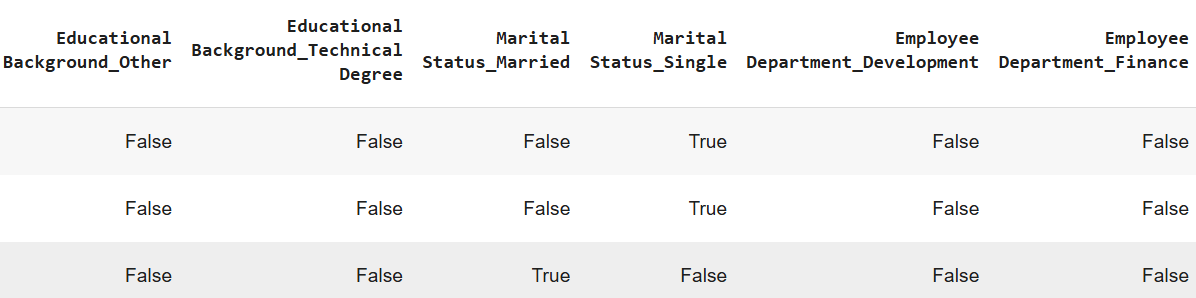

In [30]:
data = data.apply(lambda col: col.astype(int) if col.dtype == 'bool' else col)

In [31]:
data.head()

,Age,Gender,Employee Job Role,Distance From Home,Employee Education Level,Employee Environment Satisfaction,Employee Hourly Rate,Employee Job Involvement,Employee Job Level,Employee Job Satisfaction,Num_Companies_Worked,Overtime,Emp_LastSalary_Hike_Percent,Emp_Relationship_Satisfaction,Total_Work_Experience_In_Years,Training_Times_Last_Year,Emp_Work_Family_Life_Balance,Experience_Years_At_This_Company,Experience_Years_In Current Role,Years_Since_Last_Promotion,Years with Current Manager,Attrition,Performance Rating,Business_Travel_Frequency_encoded,Educational Background_Life Sciences,Educational Background_Marketing,Educational Background_Medical,Educational Background_Other,Educational Background_Technical Degree,Marital Status_Married,Marital Status_Single,Employee Department_Development,Employee Department_Finance,Employee Department_Human Resources,Employee Department_Research & Development,Employee Department_Sales
0,32,0,Sales Executive,10,3,4,55,3,2,4,1,0,12,4,10,2,2,10,7,0,8,0,3,2,0,1,0,0,0,0,1,0,0,0,0,1
1,47,0,Sales Executive,14,4,4,42,3,2,1,2,0,12,4,20,2,3,7,7,1,7,0,3,2,0,1,0,0,0,0,1,0,0,0,0,1
2,40,0,Sales Executive,5,4,4,48,2,3,1,5,1,21,3,20,2,3,18,13,1,12,0,4,1,1,0,0,0,0,1,0,0,0,0,0,1
3,41,0,Manager,10,4,2,73,2,5,4,3,0,15,2,23,2,2,21,6,12,6,0,3,2,0,0,0,0,0,0,0,0,0,1,0,0
4,60,0,Sales Executive,16,4,1,84,3,2,1,8,0,14,4,10,1,3,2,2,2,2,0,3,2,0,1,0,0,0,0,1,0,0,0,0,1


In [32]:
non_numeric_cols = data.select_dtypes(exclude=['number']).columns

In [33]:
summary = pd.DataFrame({
    'Column': non_numeric_cols,
    'Category_Count': [data[c].nunique(dropna=True) for c in non_numeric_cols]
})
print(summary)

              Column  Category_Count
0  Employee Job Role              19


In [34]:
data.shape

(1200, 36)

**Action:** Doing **Normalized_Frequency_Encoding** of the *Employee Job Role* to avoid blow up of dimentionality. This will bring into play some unnecessary ordinality, but might be still managable. May be we can do one-hot encoding of the same column and do some kind of ablation studies. **To be decided later.**

In [35]:
Freq = data['Employee Job Role'].value_counts(normalize=True)

In [36]:
data['Employee Job Role_Encoded'] = data['Employee Job Role'].map(Freq)

In [37]:
data.shape

(1200, 37)

In [38]:
data.columns

Index(['Age', 'Gender', 'Employee Job Role', 'Distance From Home',
       'Employee Education Level', 'Employee Environment Satisfaction',
       'Employee Hourly Rate', 'Employee Job Involvement',
       'Employee Job Level', 'Employee Job Satisfaction',
       'Num_Companies_Worked', 'Overtime', 'Emp_LastSalary_Hike_Percent',
       'Emp_Relationship_Satisfaction', 'Total_Work_Experience_In_Years',
       'Training_Times_Last_Year', 'Emp_Work_Family_Life_Balance',
       'Experience_Years_At_This_Company', 'Experience_Years_In Current Role',
       'Years_Since_Last_Promotion', 'Years with Current Manager', 'Attrition',
       'Performance Rating', 'Business_Travel_Frequency_encoded',
       'Educational Background_Life Sciences',
       'Educational Background_Marketing', 'Educational Background_Medical',
       'Educational Background_Other',
       'Educational Background_Technical Degree', 'Marital Status_Married',
       'Marital Status_Single', 'Employee Department_Development'

In [39]:
data = data.drop(columns=['Employee Job Role'])

In [40]:
data.shape

(1200, 36)

In [41]:
data.head()

,Age,Gender,Distance From Home,Employee Education Level,Employee Environment Satisfaction,Employee Hourly Rate,Employee Job Involvement,Employee Job Level,Employee Job Satisfaction,Num_Companies_Worked,Overtime,Emp_LastSalary_Hike_Percent,Emp_Relationship_Satisfaction,Total_Work_Experience_In_Years,Training_Times_Last_Year,Emp_Work_Family_Life_Balance,Experience_Years_At_This_Company,Experience_Years_In Current Role,Years_Since_Last_Promotion,Years with Current Manager,Attrition,Performance Rating,Business_Travel_Frequency_encoded,Educational Background_Life Sciences,Educational Background_Marketing,Educational Background_Medical,Educational Background_Other,Educational Background_Technical Degree,Marital Status_Married,Marital Status_Single,Employee Department_Development,Employee Department_Finance,Employee Department_Human Resources,Employee Department_Research & Development,Employee Department_Sales,Employee Job Role_Encoded
0,32,0,10,3,4,55,3,2,4,1,0,12,4,10,2,2,10,7,0,8,0,3,2,0,1,0,0,0,0,1,0,0,0,0,1,0.2250
1,47,0,14,4,4,42,3,2,1,2,0,12,4,20,2,3,7,7,1,7,0,3,2,0,1,0,0,0,0,1,0,0,0,0,1,0.2250
2,40,0,5,4,4,48,2,3,1,5,1,21,3,20,2,3,18,13,1,12,0,4,1,1,0,0,0,0,1,0,0,0,0,0,1,0.2250
3,41,0,10,4,2,73,2,5,4,3,0,15,2,23,2,2,21,6,12,6,0,3,2,0,0,0,0,0,0,0,0,0,1,0,0,0.0425
4,60,0,16,4,1,84,3,2,1,8,0,14,4,10,1,3,2,2,2,2,0,3,2,0,1,0,0,0,0,1,0,0,0,0,1,0.2250


**Action:** Since we are trying to predict Performance Rating, poor Performace Rating can lead to Attrition but the converse is meaningless. So, dropping the Attrition column.

**Action:** But here we are not doing row subsetting [just selecting the rows where Attrition is "Yes] since those data points can help in predicting Performance ratings [of *True Test data*] although it is never confirmed prior that such employees will ultimately quit.

In [42]:
data.drop(columns=["Attrition"], inplace=True)

In [43]:
data.shape

(1200, 35)

In [44]:
data.columns

Index(['Age', 'Gender', 'Distance From Home', 'Employee Education Level',
       'Employee Environment Satisfaction', 'Employee Hourly Rate',
       'Employee Job Involvement', 'Employee Job Level',
       'Employee Job Satisfaction', 'Num_Companies_Worked', 'Overtime',
       'Emp_LastSalary_Hike_Percent', 'Emp_Relationship_Satisfaction',
       'Total_Work_Experience_In_Years', 'Training_Times_Last_Year',
       'Emp_Work_Family_Life_Balance', 'Experience_Years_At_This_Company',
       'Experience_Years_In Current Role', 'Years_Since_Last_Promotion',
       'Years with Current Manager', 'Performance Rating',
       'Business_Travel_Frequency_encoded',
       'Educational Background_Life Sciences',
       'Educational Background_Marketing', 'Educational Background_Medical',
       'Educational Background_Other',
       'Educational Background_Technical Degree', 'Marital Status_Married',
       'Marital Status_Single', 'Employee Department_Development',
       'Employee Department_Fina

**Action:** Checking for the sanity of the "*Total_Work_Experience_In_Years*" & "*Experience_Years_At_This_Company*" & "*Experience_Years_In Current Role*" column. Ideally, it should be always Total_Work_Experience_In_Years **>=** Experience_Years_At_This_Company **>=** Experience_Years_In Current Role

In [45]:
# Create a boolean mask for rows that violate the condition
violations = ~(
    (data["Total_Work_Experience_In_Years"] >= data["Experience_Years_At_This_Company"]) &
    (data["Experience_Years_At_This_Company"] >= data["Experience_Years_In Current Role"])
)

# Show rows where the condition is violated
invalid_rows = data[violations]

print(f"Number of violations: {violations.sum()}")
invalid_rows


Number of violations: 0


,Age,Gender,Distance From Home,Employee Education Level,Employee Environment Satisfaction,Employee Hourly Rate,Employee Job Involvement,Employee Job Level,Employee Job Satisfaction,Num_Companies_Worked,Overtime,Emp_LastSalary_Hike_Percent,Emp_Relationship_Satisfaction,Total_Work_Experience_In_Years,Training_Times_Last_Year,Emp_Work_Family_Life_Balance,Experience_Years_At_This_Company,Experience_Years_In Current Role,Years_Since_Last_Promotion,Years with Current Manager,Performance Rating,Business_Travel_Frequency_encoded,Educational Background_Life Sciences,Educational Background_Marketing,Educational Background_Medical,Educational Background_Other,Educational Background_Technical Degree,Marital Status_Married,Marital Status_Single,Employee Department_Development,Employee Department_Finance,Employee Department_Human Resources,Employee Department_Research & Development,Employee Department_Sales,Employee Job Role_Encoded


**OBSERVATION:** Data is correct. No deformities.

**NOTE:** Performance Rating is given as 2, 3 and 4 . We can make two different interpretations namely they are numbers rather than labels build a regression model and predict the performance rating taking floor or ceiling values to have values only 2 ,3 and 4.  Also we can build classifiers taking performance rating to be labels and predict the class 2,3, or 4.

**NOTE:** Regression loss functions always treat the target as continuous.

But here Target is discrete ordinal.

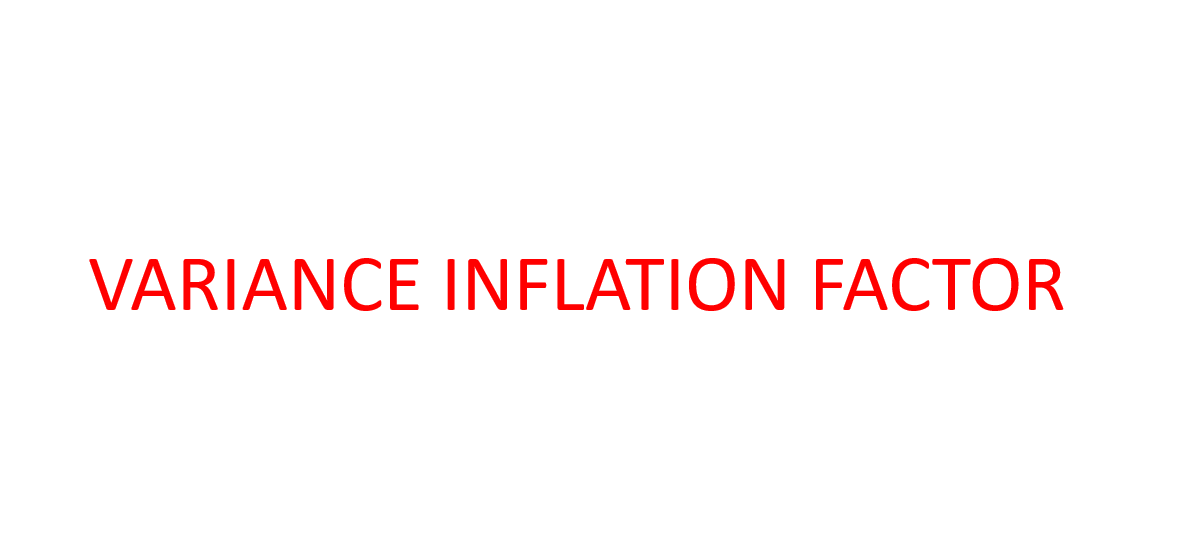

Concept of **Variance Inflation Factor**

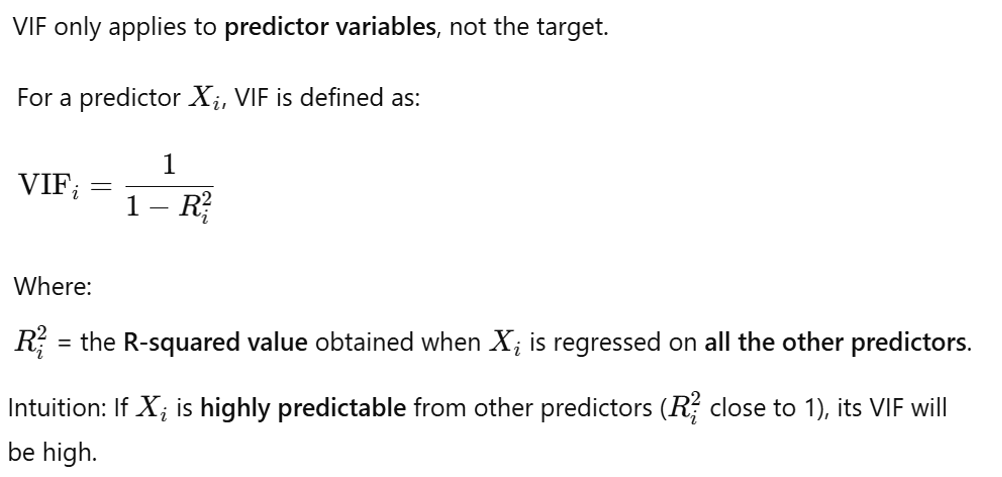

**Action:** Way towards VIF.

In [46]:
True_target = 'Performance Rating'
X = data.drop(columns=[True_target])

In [47]:
data.head(2)

,Age,Gender,Distance From Home,Employee Education Level,Employee Environment Satisfaction,Employee Hourly Rate,Employee Job Involvement,Employee Job Level,Employee Job Satisfaction,Num_Companies_Worked,Overtime,Emp_LastSalary_Hike_Percent,Emp_Relationship_Satisfaction,Total_Work_Experience_In_Years,Training_Times_Last_Year,Emp_Work_Family_Life_Balance,Experience_Years_At_This_Company,Experience_Years_In Current Role,Years_Since_Last_Promotion,Years with Current Manager,Performance Rating,Business_Travel_Frequency_encoded,Educational Background_Life Sciences,Educational Background_Marketing,Educational Background_Medical,Educational Background_Other,Educational Background_Technical Degree,Marital Status_Married,Marital Status_Single,Employee Department_Development,Employee Department_Finance,Employee Department_Human Resources,Employee Department_Research & Development,Employee Department_Sales,Employee Job Role_Encoded
0,32,0,10,3,4,55,3,2,4,1,0,12,4,10,2,2,10,7,0,8,3,2,0,1,0,0,0,0,1,0,0,0,0,1,0.225
1,47,0,14,4,4,42,3,2,1,2,0,12,4,20,2,3,7,7,1,7,3,2,0,1,0,0,0,0,1,0,0,0,0,1,0.225


In [48]:
X_numeric = X.apply(pd.to_numeric, errors='coerce') # Converting every value to numeric

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [50]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]
vif_data_sorted = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)
print(vif_data_sorted)

                                       Feature        VIF
0                                          Age  35.238166
1         Educational Background_Life Sciences  27.529037
2               Educational Background_Medical  21.461558
3                    Employee Department_Sales  18.483686
4                  Emp_LastSalary_Hike_Percent  17.275907
5              Employee Department_Development  16.378863
6                 Emp_Work_Family_Life_Balance  16.193296
7                     Employee Job Involvement  15.447374
8               Total_Work_Experience_In_Years  14.967843
9   Employee Department_Research & Development  14.579935
10                          Employee Job Level  12.423284
11                        Employee Hourly Rate  11.669148
12            Experience_Years_At_This_Company  10.644176
13                    Employee Education Level   9.256069
14            Educational Background_Marketing   9.194845
15               Emp_Relationship_Satisfaction   7.490837
16           E

In [51]:
X_numeric.drop(columns=["Age"], inplace=True)

In [52]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]
vif_data_sorted = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)
print(vif_data_sorted)

                                       Feature        VIF
0         Educational Background_Life Sciences  26.450225
1               Educational Background_Medical  20.692561
2                    Employee Department_Sales  18.412974
3                  Emp_LastSalary_Hike_Percent  17.217189
4              Employee Department_Development  16.285665
5                 Emp_Work_Family_Life_Balance  16.193203
6                     Employee Job Involvement  15.295121
7   Employee Department_Research & Development  14.451800
8                           Employee Job Level  12.422269
9                         Employee Hourly Rate  11.591262
10              Total_Work_Experience_In_Years  11.514742
11            Experience_Years_At_This_Company  10.590332
12                    Employee Education Level   8.999078
13            Educational Background_Marketing   8.845138
14               Emp_Relationship_Satisfaction   7.439024
15           Employee Environment Satisfaction   7.160231
16            

In [53]:
X_numeric.drop(columns=["Educational Background_Life Sciences","Educational Background_Medical"], inplace=True)

In [54]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]
vif_data_sorted = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)
print(vif_data_sorted)

                                       Feature        VIF
0                  Emp_LastSalary_Hike_Percent  16.266645
1                    Employee Department_Sales  16.151616
2                 Emp_Work_Family_Life_Balance  15.496415
3                     Employee Job Involvement  14.851654
4              Employee Department_Development  14.076922
5                           Employee Job Level  12.378811
6   Employee Department_Research & Development  12.292212
7               Total_Work_Experience_In_Years  11.503302
8                         Employee Hourly Rate  11.259748
9             Experience_Years_At_This_Company  10.574493
10                    Employee Education Level   8.919753
11               Emp_Relationship_Satisfaction   7.348418
12           Employee Environment Satisfaction   6.995653
13                   Employee Job Satisfaction   6.983499
14            Experience_Years_In Current Role   6.942558
15                  Years with Current Manager   6.446169
16           B

In [55]:
X_numeric.drop(columns=["Emp_LastSalary_Hike_Percent","Employee Department_Sales","Emp_Work_Family_Life_Balance"], inplace=True)

In [56]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]
vif_data_sorted = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)
print(vif_data_sorted)

                                       Feature        VIF
0                     Employee Job Involvement  13.727749
1                           Employee Job Level  12.024371
2               Total_Work_Experience_In_Years  11.394598
3             Experience_Years_At_This_Company  10.562943
4                         Employee Hourly Rate  10.421281
5                     Employee Education Level   8.647433
6                Emp_Relationship_Satisfaction   7.077630
7             Experience_Years_In Current Role   6.918740
8            Employee Environment Satisfaction   6.713289
9                    Employee Job Satisfaction   6.556646
10                  Years with Current Manager   6.441262
11           Business_Travel_Frequency_encoded   6.337362
12                    Training_Times_Last_Year   5.560385
13                   Employee Job Role_Encoded   4.637130
14                      Marital Status_Married   3.003037
15  Employee Department_Research & Development   2.912832
16            

In [57]:
X_numeric.drop(columns=["Employee Job Involvement","Employee Job Level","Total_Work_Experience_In_Years","Experience_Years_At_This_Company"], inplace=True)

In [58]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]
vif_data_sorted = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)
print(vif_data_sorted)

                                       Feature       VIF
0                         Employee Hourly Rate  9.852022
1                     Employee Education Level  8.341823
2                Emp_Relationship_Satisfaction  6.887517
3            Employee Environment Satisfaction  6.511730
4                    Employee Job Satisfaction  6.368236
5            Business_Travel_Frequency_encoded  6.180476
6             Experience_Years_In Current Role  5.771211
7                     Training_Times_Last_Year  5.473328
8                   Years with Current Manager  5.215464
9                    Employee Job Role_Encoded  4.474937
10                      Marital Status_Married  2.978377
11  Employee Department_Research & Development  2.861225
12                       Marital Status_Single  2.410924
13             Employee Department_Development  2.368194
14                        Num_Companies_Worked  2.277023
15                          Distance From Home  2.249534
16                  Years_Since

In [59]:
X_numeric.drop(columns=["Employee Hourly Rate","Employee Education Level"], inplace=True)

In [60]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]
vif_data_sorted = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)
print(vif_data_sorted)

                                       Feature       VIF
0                Emp_Relationship_Satisfaction  6.656734
1            Employee Environment Satisfaction  6.375666
2                    Employee Job Satisfaction  6.169474
3            Business_Travel_Frequency_encoded  5.952006
4             Experience_Years_In Current Role  5.769241
5                     Training_Times_Last_Year  5.345276
6                   Years with Current Manager  5.161337
7                    Employee Job Role_Encoded  4.261136
8                       Marital Status_Married  2.923236
9   Employee Department_Research & Development  2.665059
10                       Marital Status_Single  2.372062
11             Employee Department_Development  2.304346
12                          Distance From Home  2.216347
13                        Num_Companies_Worked  2.181650
14                  Years_Since_Last_Promotion  2.148862
15                                      Gender  1.672333
16            Educational Backg

**Decision:** The above list of columns are to be selected.

In [61]:
selected_features = [
    "Emp_Relationship_Satisfaction",
    "Employee Environment Satisfaction",
    "Employee Job Satisfaction",
    "Business_Travel_Frequency_encoded",
    "Experience_Years_In Current Role",
    "Training_Times_Last_Year",
    "Years with Current Manager",
    "Employee Job Role_Encoded",
    "Marital Status_Married",
    "Employee Department_Research & Development",
    "Marital Status_Single",
    "Employee Department_Development",
    "Distance From Home",
    "Num_Companies_Worked",
    "Years_Since_Last_Promotion",
    "Gender",
    "Educational Background_Marketing",
    "Overtime",
    "Employee Department_Human Resources",
    "Employee Department_Finance",
    "Educational Background_Technical Degree",
    "Educational Background_Other",
    "Performance Rating"
]

In [62]:
len(selected_features)

23

In [63]:
# Keep only the selected features
data = data[selected_features].copy()

print("Shape after subsetting:", data.shape)
print("Remaining columns:", data.columns.tolist())

Shape after subsetting: (1200, 23)
Remaining columns: ['Emp_Relationship_Satisfaction', 'Employee Environment Satisfaction', 'Employee Job Satisfaction', 'Business_Travel_Frequency_encoded', 'Experience_Years_In Current Role', 'Training_Times_Last_Year', 'Years with Current Manager', 'Employee Job Role_Encoded', 'Marital Status_Married', 'Employee Department_Research & Development', 'Marital Status_Single', 'Employee Department_Development', 'Distance From Home', 'Num_Companies_Worked', 'Years_Since_Last_Promotion', 'Gender', 'Educational Background_Marketing', 'Overtime', 'Employee Department_Human Resources', 'Employee Department_Finance', 'Educational Background_Technical Degree', 'Educational Background_Other', 'Performance Rating']


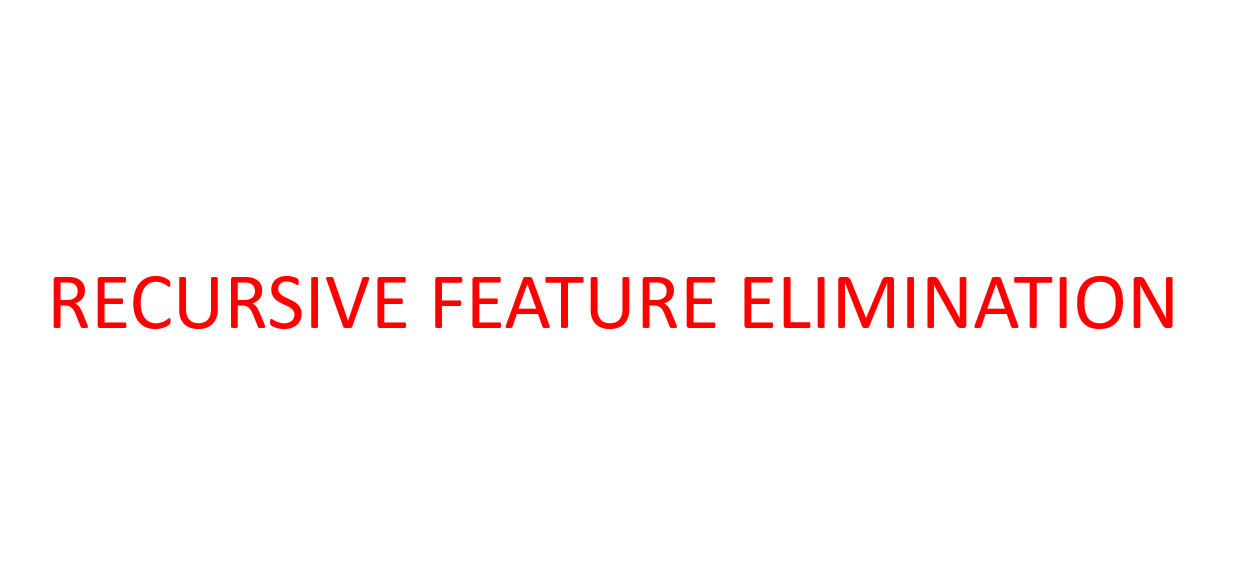

Concept of **Recursive Feature Elimination**

**Recursive Feature Elimination** (RFE) is a feature selection method that selects important predictors by recursively removing the least important ones.

It uses an estimator (like linear regression, logistic regression, or tree-based models) to measure feature importance. So, RFE is model-based.

The goal is to find a subset of features that contribute the most to predicting the target.



**Action:** Performing Recursive Feature Elimination to reduce dimension even further if possible.

**Note:** RFE demands model building. In our case the target is Ordinal in nature.

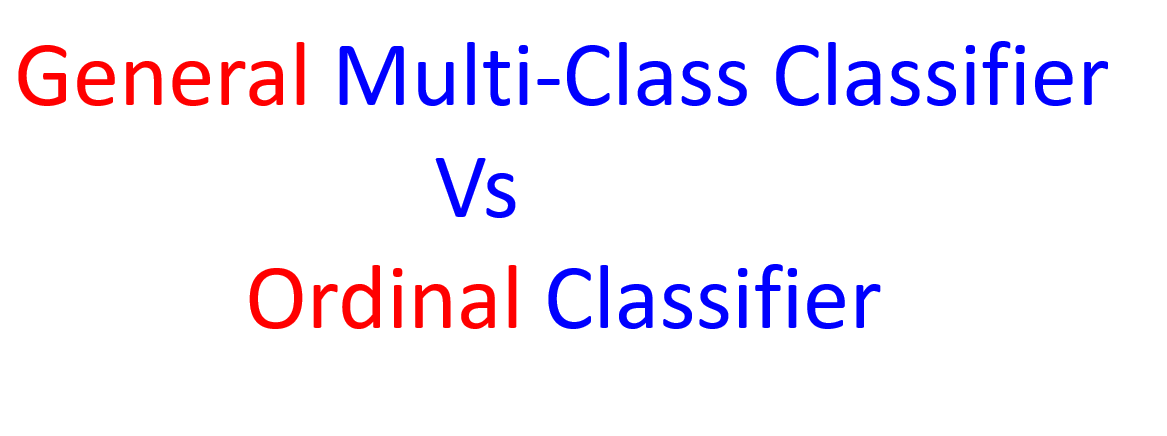

**DIFFERENCE BETWEEN A GENERAL MULTI-CLASS CLASSIFIER AND AN ORDINAL CLASSIFIER**

**General classifiers (multiclass)**
Treat each class as independent categories.There is NO natural ordering of the various values of the Target. **Example:** Predicting fruit type = {apple, banana, orange}. Misclassifying apple as orange is just as bad as apple as banana.

**Ordinal classifiers**
Designed for targets that have a natural order, but may not be evenly spaced.
Example: Performance rating = {2 = Below Average, 3 = Average, 4 = Above Average}.
Here, 4 > 3 > 2. Misclassifying a “2” as a “3” need not be as serious as misclassifying a “2” as a “4”.

**THRESHOLD-BASED Approach of Ordinal Classification**

A common approach is threshold-based ordinal classification:

For k ordered classes, create k-1 binary classification tasks:

**Task 1:** Is the rating ≥ 3?

**Task 2:** Is the rating ≥ 4? and so on.


Each task is trained as a binary classifier.


During prediction, you shall perform the following check sequentially.

If y >= 3 is False → label = 2.

If y >= 3 is True but y >= 4 is False → label = 3.

If both are True → label = 4.

**y_ge3:** Converts ratings {2,3,4} into {0,1} depending on whether they’re ≥3.

2 → 0

3 → 1

4 → 1

**y_ge4** : Converts ratings {2,3,4} into {0,1} depending on whether they’re ≥4.

2 → 0

3 → 0

4 → 1


So now you have two binary tasks, each solvable with any classifier.

Concept of **SUPPORT**, **MACRO-AVERAGE**, **WEIGHTED-AVERAGE**

**Support:** The number of true instances of each class in your dataset (the ground truth count).

If the test set has 240 samples with counts:

Class 2 → 39

Class 3 → 175

Class 4 → 26  then the support values shown will be 39, 175, and 26.

**Support just tells you how many test samples belong to each class** — so you can interpret precision/recall in context.

**Macro Average**

The simple (unweighted) mean of a metric (precision, recall, or F1) across all classes.

**Example Macro F1**

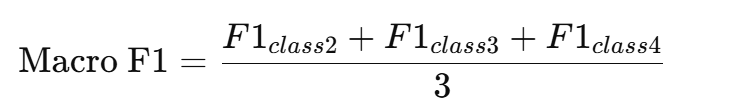

**Weighted Average**

The average of a metric across all classes, weighted by support (the number of true samples).

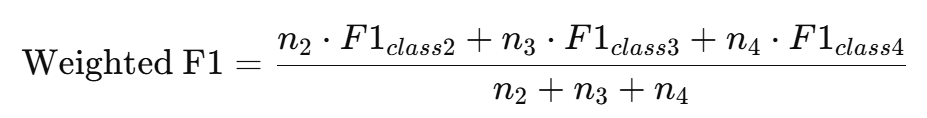

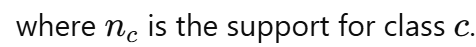

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [65]:
X = data.drop(columns=["Performance Rating"])   # Features
y = data["Performance Rating"]                  # Target

In [66]:
y_ge3 = (y >= 3).astype(int)   # Task 1
y_ge4 = (y >= 4).astype(int)   # Task 2

**Action:** Checking for possible data imbalance.

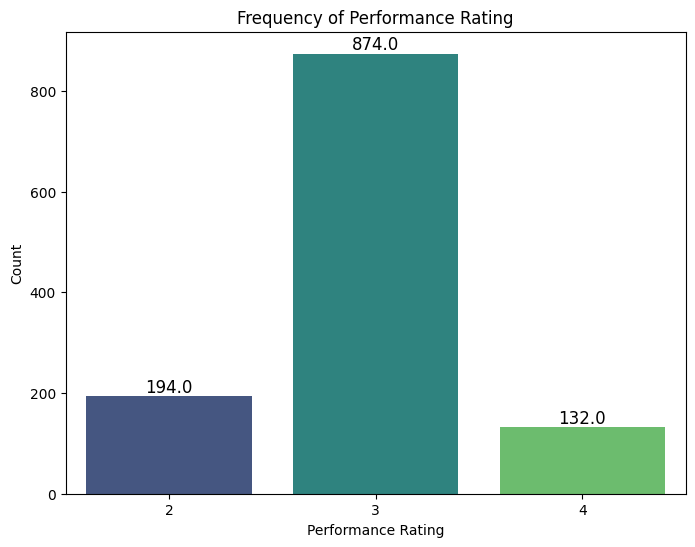

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# target column
target_col = "Performance Rating"

plt.figure(figsize=(8, 6))

# plot countplot (categorical histogram)
ax = sns.countplot(x=target_col, data=data, palette="viridis")

# add counts on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12)

plt.title(f"Frequency of {target_col}")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.show()


**CONCLUSION:** Target dominated on by 3 rating. Imbalanced dataset.

**NOTE:** Some experts caution against correcting class imbalance, arguing that it can erase the true representation of the data and cause models to fail once deployed. **Oversampling** has its own drawbacks—simple oversampling of the minority class may just duplicate records. **Undersampling**, on the other hand, can be even more harmful since it significantly reduces the size of the dataset.

**NOTE:** With **SMOTE**, the issue is that new minority samples are created along straight lines between existing ones. This restricts the synthetic points to lie within the convex hull of the original minority data. As a result, SMOTE cannot extrapolate into regions where minority cases might realistically occur; it only interpolates among what is already there. This may distort the true distribution of the minority class. Ultimately, the dataset may look balanced on the surface but is misleading at its core, and models trained on such artificially generated patterns may fail to generalize because those patterns never existed in reality.

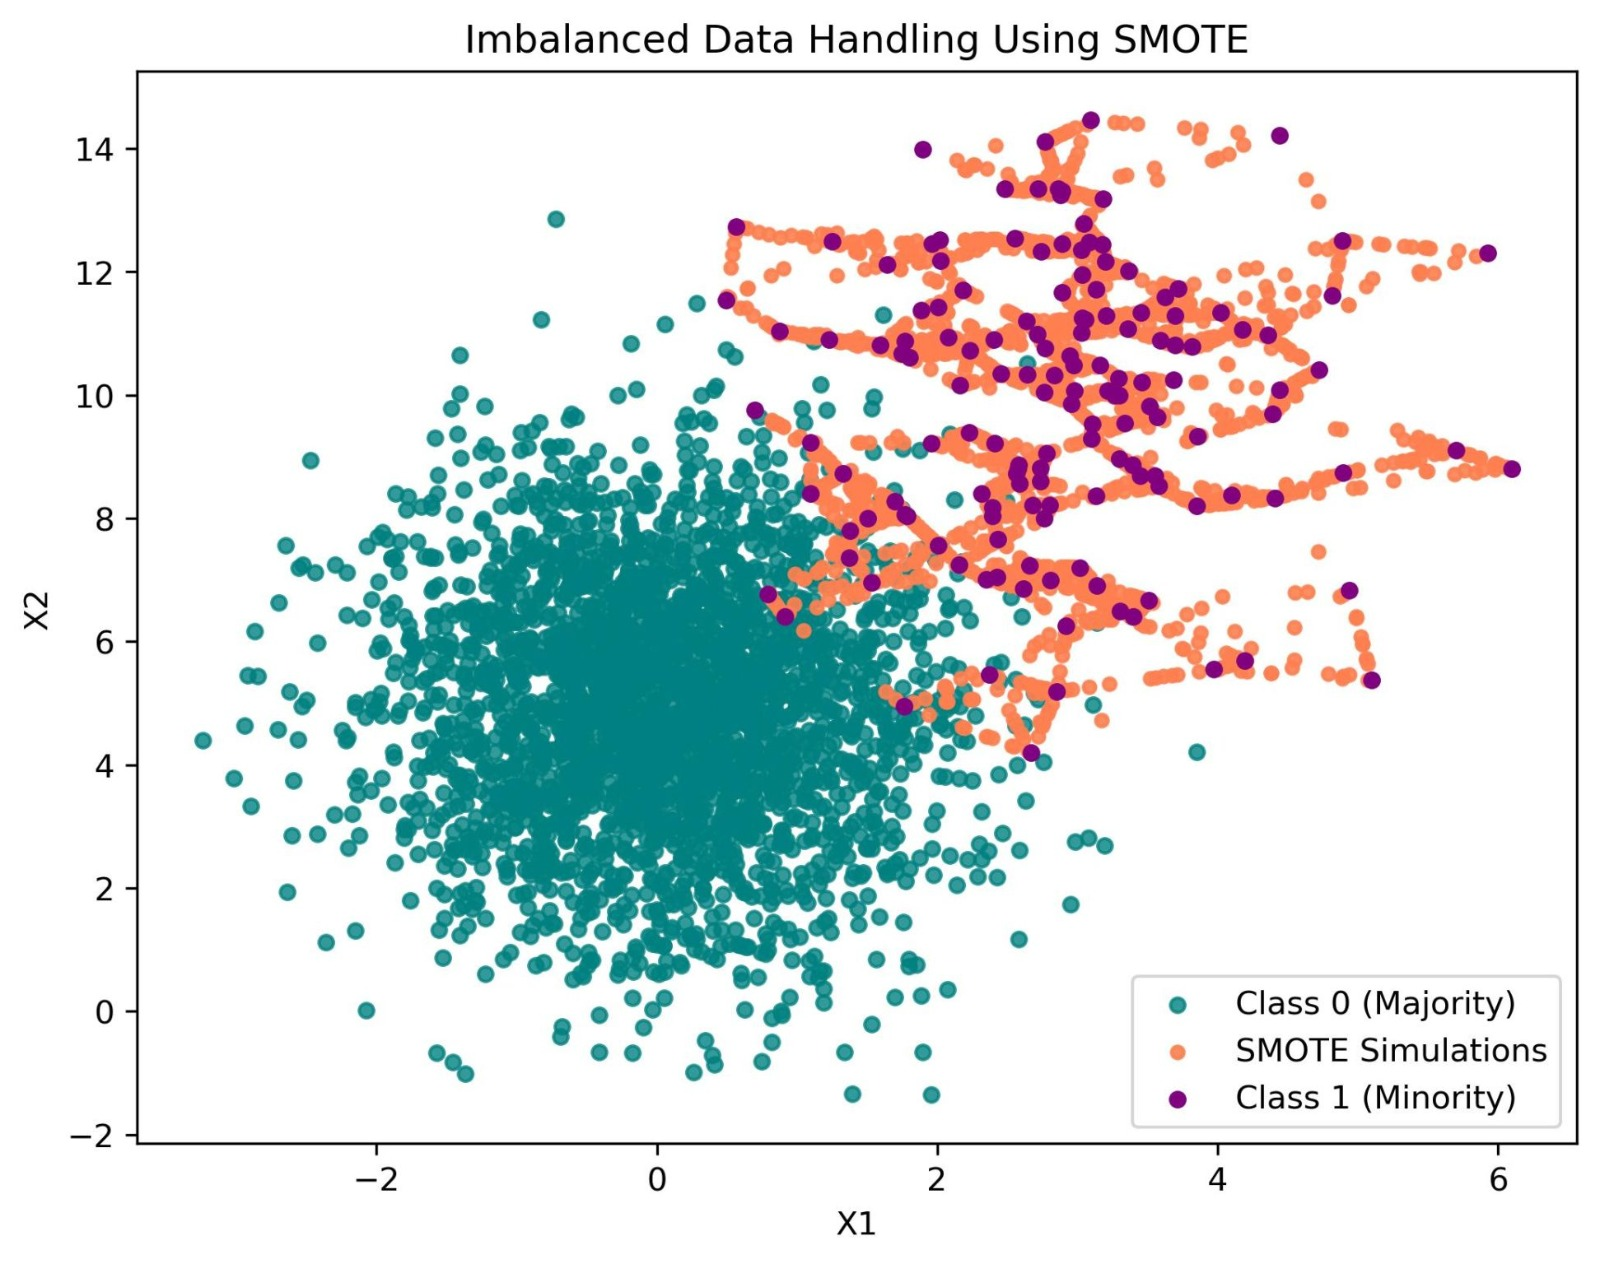

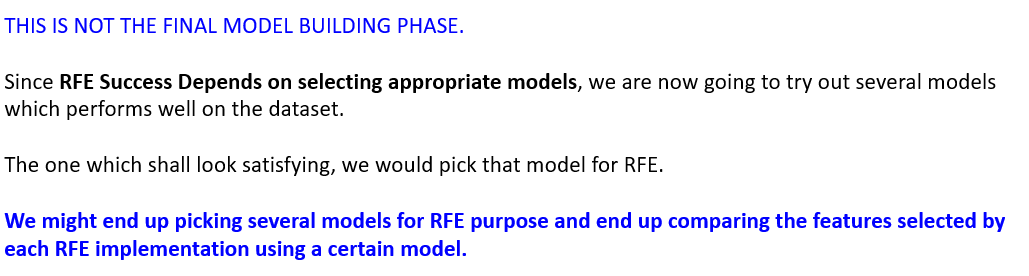

**Action:** Trying out with only **Logistic Regression.**

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
y_ge3_train, y_ge3_test = y_ge3[y_train.index], y_ge3[y_test.index]
y_ge4_train, y_ge4_test = y_ge4[y_train.index], y_ge4[y_test.index]

In [69]:
clf_ge3 = LogisticRegression().fit(X_train, y_ge3_train)
clf_ge4 = LogisticRegression().fit(X_train, y_ge4_train)

In [70]:
def predict_ordinal(X):
    # Probabilities for each threshold
    p_ge3 = clf_ge3.predict_proba(X)[:, 1]
    p_ge4 = clf_ge4.predict_proba(X)[:, 1]

    preds = []
    for p3, p4 in zip(p_ge3, p_ge4):
        if p3 < 0.5:        # Likely < 3 → class 2
            preds.append(2)
        elif p4 < 0.5:      # Likely >= 3 but < 4 → class 3
            preds.append(3)
        else:               # Likely >= 4 → class 4
            preds.append(4)
    return np.array(preds)

In [71]:
y_pred = predict_ordinal(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           2      0.655     0.463     0.543        41
           3      0.768     0.953     0.850       170
           4      0.000     0.000     0.000        29

    accuracy                          0.754       240
   macro avg      0.474     0.472     0.464       240
weighted avg      0.656     0.754     0.695       240



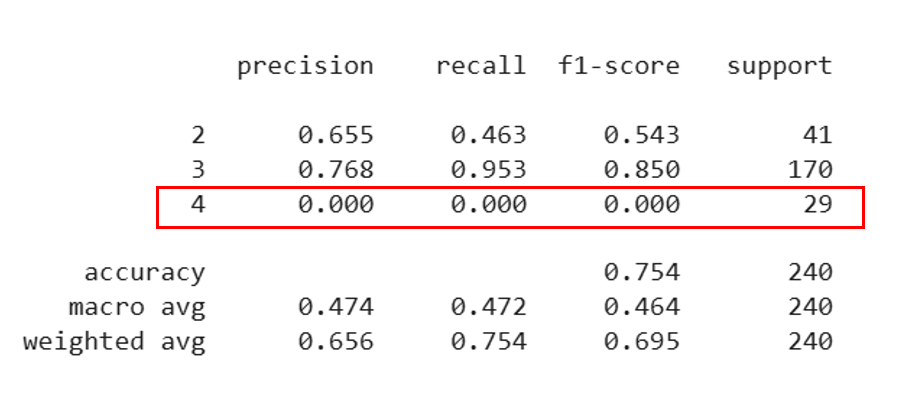

**Conclusion:** For those cases where Performance Rating was 4, it is a big flop.

**Action:** Trying out with *Logistic Regression with class_weight only* and *Logistic Regression with class_weight + SMOTE*

**NOTE:** Logistic Regression minimizes the log-loss (cross-entropy). By default, each sample contributes equally to the loss. If the dataset is imbalanced (e.g., 90% class 0, 10% class 1), the model will be biased toward predicting the majority class, because misclassifying a minority sample barely changes the total loss.

class_weight="balanced" assigns higher weights to minority class.
When you set class_weight="balanced" in scikit-learn:

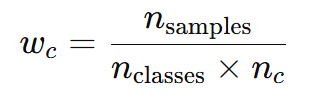

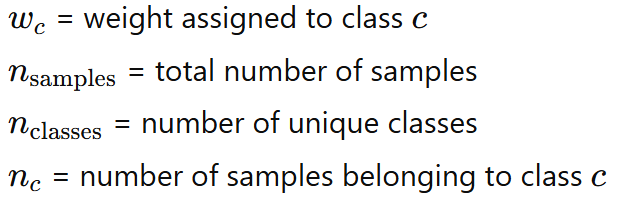

Thus in effect, **minority classes get larger weights** whereas **majority classes get smaller weights.**

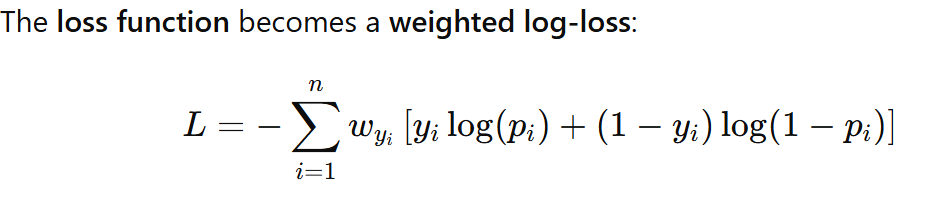

Misclassifying minority samples now contributes a larger penalty.
This pushes the decision boundary toward favoring the minority class.

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [73]:
y_ge3_train = y_ge3[y_train.index]
y_ge3_test  = y_ge3[y_test.index]
y_ge4_train = y_ge4[y_train.index]
y_ge4_test  = y_ge4[y_test.index]

**Logistic Regression with Class Weights**

In [74]:
clf_ge3_w = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=1)
clf_ge4_w = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=1)

In [75]:
clf_ge3_w.fit(X_train, y_ge3_train)
clf_ge4_w.fit(X_train, y_ge4_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1)

**Logistic Regression with SMOTE + Class Weights**

In [76]:
from imblearn.over_sampling import SMOTE

In [77]:
smote = SMOTE(random_state=1)

X_train_ge3, y_train_ge3 = smote.fit_resample(X_train, y_ge3_train)
X_train_ge4, y_train_ge4 = smote.fit_resample(X_train, y_ge4_train)

clf_ge3_sm = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=1)
clf_ge4_sm = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=1)

clf_ge3_sm.fit(X_train_ge3, y_train_ge3)
clf_ge4_sm.fit(X_train_ge4, y_train_ge4)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1)

**X**→ feature matrix (test set samples).

**clf_ge3** → a binary classifier trained to answer: “Is y ≥ 3?”

**clf_ge4** → another binary classifier trained to answer: “Is y ≥ 4?”

So instead of training a single 3-class model, we split the problem into two threshold tasks.

predict_proba(X) gives probabilities for both classes ([P(y=0), P(y=1)]).

[:,1] extracts the probability of y=1 (i.e., probability that the condition is true).

p_ge3[i] = probability sample i has rating ≥ 3

p_ge4[i] = probability sample i has rating ≥ 4

**Case 1:** If probability(y ≥ 3) < 0.5 → predict 2

**Case 2:** Else, if probability(y ≥ 4) < 0.5 → predict 3

**Case 3:** Else → predict 4

In [78]:
def predict_ordinal(X, clf_ge3, clf_ge4):
    p_ge3 = clf_ge3.predict_proba(X)[:, 1]
    p_ge4 = clf_ge4.predict_proba(X)[:, 1]

    preds = []
    for p3, p4 in zip(p_ge3, p_ge4):
        if p3 < 0.5:
            preds.append(2)   # Likely < 3
        elif p4 < 0.5:
            preds.append(3)   # Likely >=3 but <4
        else:
            preds.append(4)   # Likely >=4
    return np.array(preds)

In [79]:
y_pred_w  = predict_ordinal(X_test, clf_ge3_w, clf_ge4_w)
y_pred_sm = predict_ordinal(X_test, clf_ge3_sm, clf_ge4_sm)

In [80]:
print("=== Logistic Regression with Class Weights ===")
print(classification_report(y_test, y_pred_w, digits=3))

print("\n=== Logistic Regression with SMOTE + Class Weights ===")
print(classification_report(y_test, y_pred_sm, digits=3))


=== Logistic Regression with Class Weights ===
              precision    recall  f1-score   support

           2      0.508     0.821     0.627        39
           3      0.783     0.309     0.443       175
           4      0.120     0.500     0.194        26

    accuracy                          0.412       240
   macro avg      0.470     0.543     0.421       240
weighted avg      0.666     0.412     0.446       240


=== Logistic Regression with SMOTE + Class Weights ===
              precision    recall  f1-score   support

           2      0.565     0.667     0.612        39
           3      0.819     0.697     0.753       175
           4      0.133     0.231     0.169        26

    accuracy                          0.642       240
   macro avg      0.506     0.532     0.511       240
weighted avg      0.703     0.642     0.667       240



**Conclusion:** Some improvement in '4' cases.

CONCEPT OF **t-distributed Stochastic Neighbourhood Embedding (t-SNE)**

t-SNE is a nonlinear embedding method used to turn high-dimensional data into a 2-D (or 3-D) picture that preserves local neighborhoods—i.e., points that were near each other in the original space tend to stay near each other in the plot.

In classification, a decision boundary separates regions of the feature space assigned to different classes. High-dimensional data makes it impossible to “see” these boundaries directly.

By embedding the data into 2-D with t-SNE:

If classes are well separated, you’ll see clear regions in the scatterplot. This suggests the decision boundary could be relatively simple.

If classes overlap or interleave, you’ll see mixed clusters, hinting at a more complex nonlinear boundary.

It can also help to detect natural Clusters. BUT the distances between clusters are not reliable — t-SNE is designed to preserve local structure, not global distances.

**NOTE:** Nonlinear embeddings like t-SNE are good for high-dimensional categorical data. Let's Plot t-SNE in 2D with colors by class.
If classes 2 & 4 overlap heavily, that shall explain why models struggle.

**Action:** Checking for nature of Decision boundary.

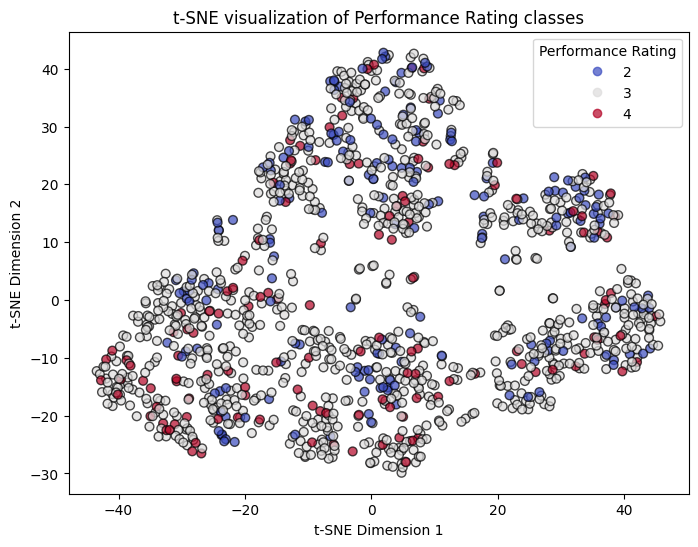

In [81]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# X = features, y = target ("Performance Rating")

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_embedded = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1],
                      c=y, cmap="coolwarm", alpha=0.7, s=40, edgecolors="k")

plt.title("t-SNE visualization of Performance Rating classes")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(*scatter.legend_elements(), title="Performance Rating")
plt.show()


**Conclusion:** Linear decision boundary is not present.

**Note:** Logistic regression is linear → it can only draw straight-line decision boundaries.

**Action:** Moving beyond Logistic Regression

**Action:** Trying tree-based models.

**Action:** Trying with RandomForestClassifier.

**Action:** Using **ADASYN** [**ADA**ptive **SYN**thetic Sampling] instead of SMOTE.

**SMOTE** vs **ADASYN**

For each minority sample, SMOTE finds its k nearest neighbors (minority samples).

It randomly picks one neighbor and creates a synthetic sample on the line between the original and the neighbor.Thus, new synthetic points lie in the convex hull of the minority class.

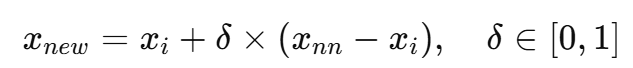

Creates synthetic points even in easy areas (where minority is already dense).

Stays inside convex hull — cannot explore new regions where minority points might exist.

**ADASYN** improves on SMOTE by making oversampling **adaptive**

Compute the class imbalance ratio:

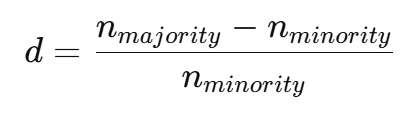

This decides how many synthetic samples to generate.

It also decides the **Difficulty Ratio** associated with each minority sample.

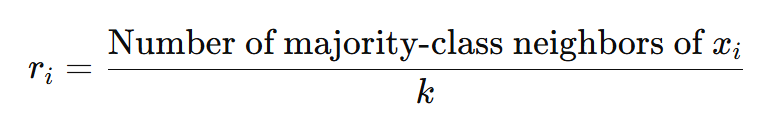

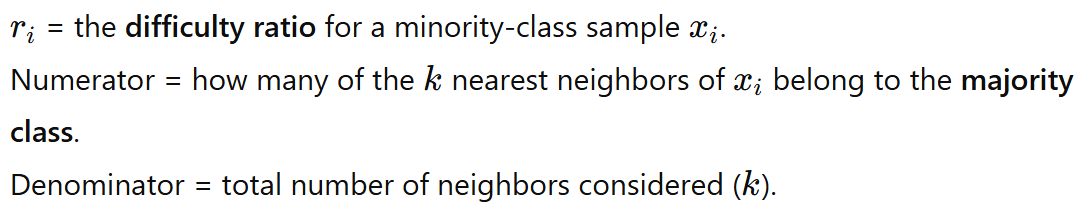

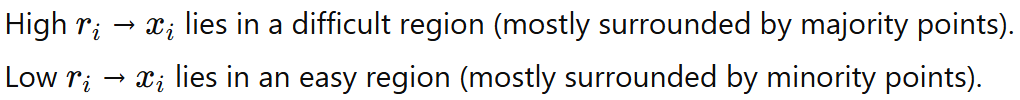

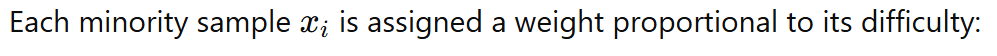

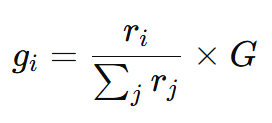

Thus, more synthetic samples are generated for minority samples in harder regions.

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, recall_score, confusion_matrix
from imblearn.over_sampling import ADASYN

RANDOM_STATE = 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Create binary targets for thresholds
y_ge3_train = (y_train >= 3).astype(int)
y_ge4_train = (y_train >= 4).astype(int)

# ---------------------------
# 2) Oversample with ADASYN
# ---------------------------
ada = ADASYN(random_state=RANDOM_STATE)
X_train_ge3, y_train_ge3 = ada.fit_resample(X_train, y_ge3_train)
X_train_ge4, y_train_ge4 = ada.fit_resample(X_train, y_ge4_train)

# ---------------------------
# 3) Train threshold models
# ---------------------------
clf_ge3 = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
clf_ge4 = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

clf_ge3.fit(X_train_ge3, y_train_ge3)
clf_ge4.fit(X_train_ge4, y_train_ge4)

# ---------------------------
# 4) Ordinal prediction with thresholds
# ---------------------------
def predict_ordinal(X, clf_ge3, clf_ge4, thr_ge3=0.5, thr_ge4=0.5):
    p_ge3 = clf_ge3.predict_proba(X)[:, 1]
    p_ge4 = clf_ge4.predict_proba(X)[:, 1]

    preds = []
    for p3, p4 in zip(p_ge3, p_ge4):
        if p3 < thr_ge3:
            preds.append(2)
        elif p4 < thr_ge4:
            preds.append(3)
        else:
            preds.append(4)
    return np.array(preds)

# ---------------------------
# 5) Threshold tuning
# ---------------------------

# Note : We want to tune the probability thresholds used in that decision rule, instead of always assuming 0.5.

def tune_thresholds(clf_ge3, clf_ge4, X_eval, y_eval, mode="f1_class4"):
    thr_vals = np.linspace(0.3, 0.7, 9)
    best_score = -1
    best_thr = (0.5, 0.5)
    best_pred = None

    for t3 in thr_vals:
        for t4 in thr_vals:
            y_pred = predict_ordinal(X_eval, clf_ge3, clf_ge4, thr_ge3=t3, thr_ge4=t4)
            if mode == "f1_class4":
                score = f1_score(y_eval, y_pred, labels=[4], average="macro", zero_division=0)
            elif mode == "recall_class4":
                score = recall_score(y_eval, y_pred, labels=[4], average="macro", zero_division=0)
            else:
                score = f1_score(y_eval, y_pred, average="macro", zero_division=0)

            if score > best_score:
                best_score = score
                best_thr = (t3, t4)
                best_pred = y_pred

    return best_thr, best_score, best_pred

# ---------------------------
# 6) Run tuning and report
# ---------------------------
mode = "f1_class4"  # or "recall_class4"
best_thr, best_score, best_pred = tune_thresholds(clf_ge3, clf_ge4, X_test, y_test, mode=mode)

print(f"Best thresholds: thr_ge3={best_thr[0]:.2f}, thr_ge4={best_thr[1]:.2f}")
print(f"Best {mode}: {best_score:.3f}\n")

print("Classification report:")
print(classification_report(y_test, best_pred, digits=3))

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, best_pred, labels=[2, 3, 4]))


Best thresholds: thr_ge3=0.65, thr_ge4=0.30
Best f1_class4: 0.175

Classification report:
              precision    recall  f1-score   support

           2      0.895     0.872     0.883        39
           3      0.845     0.714     0.774       175
           4      0.130     0.269     0.175        26

    accuracy                          0.692       240
   macro avg      0.623     0.618     0.611       240
weighted avg      0.775     0.692     0.727       240

Confusion matrix (rows=true, cols=pred):
[[ 34   4   1]
 [  4 125  46]
 [  0  19   7]]


**Action:** Trying with XGB Classifier.

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, recall_score, confusion_matrix
from imblearn.over_sampling import ADASYN
from xgboost import XGBClassifier

RANDOM_STATE = 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Create binary targets for thresholds
y_ge3_train = (y_train >= 3).astype(int)
y_ge4_train = (y_train >= 4).astype(int)

# ---------------------------
# 2) Oversample with ADASYN
# ---------------------------
ada = ADASYN(random_state=RANDOM_STATE)
X_train_ge3, y_train_ge3 = ada.fit_resample(X_train, y_ge3_train)
X_train_ge4, y_train_ge4 = ada.fit_resample(X_train, y_ge4_train)

# ---------------------------
# 3) Train threshold models (XGBClassifier)
# ---------------------------
clf_ge3 = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

clf_ge4 = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

clf_ge3.fit(X_train_ge3, y_train_ge3)
clf_ge4.fit(X_train_ge4, y_train_ge4)

# ---------------------------
# 4) Ordinal prediction with thresholds
# ---------------------------
def predict_ordinal(X, clf_ge3, clf_ge4, thr_ge3=0.5, thr_ge4=0.5):
    p_ge3 = clf_ge3.predict_proba(X)[:, 1]
    p_ge4 = clf_ge4.predict_proba(X)[:, 1]

    preds = []
    for p3, p4 in zip(p_ge3, p_ge4):
        if p3 < thr_ge3:
            preds.append(2)
        elif p4 < thr_ge4:
            preds.append(3)
        else:
            preds.append(4)
    return np.array(preds)

# ---------------------------
# 5) Threshold tuning
# ---------------------------
def tune_thresholds(clf_ge3, clf_ge4, X_eval, y_eval, mode="f1_class4"):
    thr_vals = np.linspace(0.3, 0.7, 9)
    best_score = -1
    best_thr = (0.5, 0.5)
    best_pred = None

    for t3 in thr_vals:
        for t4 in thr_vals:
            y_pred = predict_ordinal(X_eval, clf_ge3, clf_ge4, thr_ge3=t3, thr_ge4=t4)
            if mode == "f1_class4":
                score = f1_score(y_eval, y_pred, labels=[4], average="macro", zero_division=0)
            elif mode == "recall_class4":
                score = recall_score(y_eval, y_pred, labels=[4], average="macro", zero_division=0)
            else:
                score = f1_score(y_eval, y_pred, average="macro", zero_division=0)

            if score > best_score:
                best_score = score
                best_thr = (t3, t4)
                best_pred = y_pred

    return best_thr, best_score, best_pred

# ---------------------------
# 6) Run tuning and report
# ---------------------------
mode = "f1_class4"  # or "recall_class4"
best_thr, best_score, best_pred = tune_thresholds(clf_ge3, clf_ge4, X_test, y_test, mode=mode)

print(f"Best thresholds: thr_ge3={best_thr[0]:.2f}, thr_ge4={best_thr[1]:.2f}")
print(f"Best {mode}: {best_score:.3f}\n")

print("Classification report:")
print(classification_report(y_test, best_pred, digits=3))

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, best_pred, labels=[2, 3, 4]))

Best thresholds: thr_ge3=0.30, thr_ge4=0.30
Best f1_class4: 0.245

Classification report:
              precision    recall  f1-score   support

           2      0.879     0.744     0.806        39
           3      0.837     0.880     0.858       175
           4      0.261     0.231     0.245        26

    accuracy                          0.787       240
   macro avg      0.659     0.618     0.636       240
weighted avg      0.781     0.787     0.783       240

Confusion matrix (rows=true, cols=pred):
[[ 29  10   0]
 [  4 154  17]
 [  0  20   6]]


**Action:** Trying with CatBoost.

In [84]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00


In [85]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, recall_score, confusion_matrix
from imblearn.over_sampling import ADASYN
from catboost import CatBoostClassifier

RANDOM_STATE = 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Create binary targets for thresholds
y_ge3_train = (y_train >= 3).astype(int)
y_ge4_train = (y_train >= 4).astype(int)

# ---------------------------
# 2) Oversample with ADASYN
# ---------------------------
ada = ADASYN(random_state=RANDOM_STATE)
X_train_ge3, y_train_ge3 = ada.fit_resample(X_train, y_ge3_train)
X_train_ge4, y_train_ge4 = ada.fit_resample(X_train, y_ge4_train)

# ---------------------------
# 3) Train threshold models (CatBoost)
# ---------------------------
clf_ge3 = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False
)

clf_ge4 = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False
)

clf_ge3.fit(X_train_ge3, y_train_ge3)
clf_ge4.fit(X_train_ge4, y_train_ge4)

# ---------------------------
# 4) Ordinal prediction with thresholds
# ---------------------------
def predict_ordinal(X, clf_ge3, clf_ge4, thr_ge3=0.5, thr_ge4=0.5):
    p_ge3 = clf_ge3.predict_proba(X)[:, 1]
    p_ge4 = clf_ge4.predict_proba(X)[:, 1]

    preds = []
    for p3, p4 in zip(p_ge3, p_ge4):
        if p3 < thr_ge3:
            preds.append(2)
        elif p4 < thr_ge4:
            preds.append(3)
        else:
            preds.append(4)
    return np.array(preds)

# ---------------------------
# 5) Threshold tuning
# ---------------------------
def tune_thresholds(clf_ge3, clf_ge4, X_eval, y_eval, mode="f1_class4"):
    thr_vals = np.linspace(0.3, 0.7, 9)
    best_score = -1
    best_thr = (0.5, 0.5)
    best_pred = None

    for t3 in thr_vals:
        for t4 in thr_vals:
            y_pred = predict_ordinal(X_eval, clf_ge3, clf_ge4, thr_ge3=t3, thr_ge4=t4)
            if mode == "f1_class4":
                score = f1_score(y_eval, y_pred, labels=[4], average="macro", zero_division=0)
            elif mode == "recall_class4":
                score = recall_score(y_eval, y_pred, labels=[4], average="macro", zero_division=0)
            else:
                score = f1_score(y_eval, y_pred, average="macro", zero_division=0)

            if score > best_score:
                best_score = score
                best_thr = (t3, t4)
                best_pred = y_pred

    return best_thr, best_score, best_pred

# ---------------------------
# 6) Run tuning and report
# ---------------------------
mode = "f1_class4"  # or "recall_class4"
best_thr, best_score, best_pred = tune_thresholds(clf_ge3, clf_ge4, X_test, y_test, mode=mode)

print(f"Best thresholds: thr_ge3={best_thr[0]:.2f}, thr_ge4={best_thr[1]:.2f}")
print(f"Best {mode}: {best_score:.3f}\n")

print("Classification report:")
print(classification_report(y_test, best_pred, digits=3))

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, best_pred, labels=[2, 3, 4]))


Best thresholds: thr_ge3=0.30, thr_ge4=0.30
Best f1_class4: 0.192

Classification report:
              precision    recall  f1-score   support

           2      0.889     0.821     0.853        39
           3      0.848     0.863     0.856       175
           4      0.192     0.192     0.192        26

    accuracy                          0.783       240
   macro avg      0.643     0.625     0.634       240
weighted avg      0.784     0.783     0.783       240

Confusion matrix (rows=true, cols=pred):
[[ 32   6   1]
 [  4 151  20]
 [  0  21   5]]


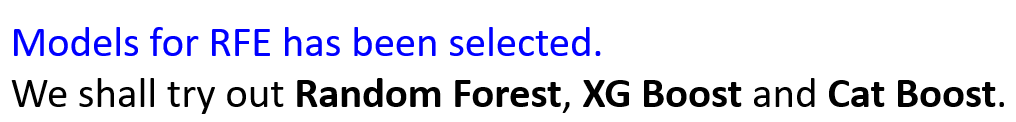

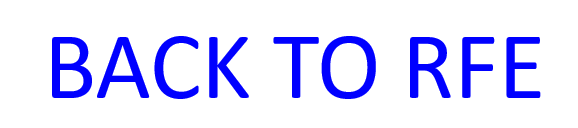

**Action:** RFE using Random Forest

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# Define Random Forest model
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# -----------------------------
# Apply RFE
# -----------------------------
# For example, select top 10 features
selector = RFE(estimator=rf, n_features_to_select=10, step=1)
selector = selector.fit(X_train, y_train)

# -----------------------------
# Collect results
# -----------------------------
# Boolean mask of selected features
selected_mask = selector.support_
# Ranking of features (1 = selected)
feature_ranking = selector.ranking_

# Create summary DataFrame
rfe_rf = pd.DataFrame({
    "Feature": X.columns,
    "Selected": selected_mask,
    "Rank": feature_ranking
}).sort_values(by="Rank")

print("Top Features Selected by RFE with Random Forest:")
print(rfe_rf[rfe_rf["Selected"] == True])

print("\nAll Features Ranked:")
print(rfe_rf)

# -----------------------------
# Reduced feature set
# -----------------------------
X_train_rfe = selector.transform(X_train)
X_test_rfe = selector.transform(X_test)

print("\nShape before RFE:", X_train.shape)
print("Shape after RFE:", X_train_rfe.shape)

Top Features Selected by RFE with Random Forest:
                              Feature  Selected  Rank
0       Emp_Relationship_Satisfaction      True     1
1   Employee Environment Satisfaction      True     1
2           Employee Job Satisfaction      True     1
4    Experience_Years_In Current Role      True     1
6          Years with Current Manager      True     1
5            Training_Times_Last_Year      True     1
7           Employee Job Role_Encoded      True     1
13               Num_Companies_Worked      True     1
12                 Distance From Home      True     1
14         Years_Since_Last_Promotion      True     1

All Features Ranked:
                                       Feature  Selected  Rank
0                Emp_Relationship_Satisfaction      True     1
1            Employee Environment Satisfaction      True     1
2                    Employee Job Satisfaction      True     1
4             Experience_Years_In Current Role      True     1
6                   

**Action:** RFE with XGB

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier

# -----------------------------
# Remap labels
# -----------------------------
y_mapped = y.map({2: 0, 3: 1, 4: 2})

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped
)

# -----------------------------
# Define XGBClassifier model
# -----------------------------
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="multi:softmax",   # multiclass
    num_class=3,                 # since we mapped to {0,1,2}
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# Apply RFE
# -----------------------------
selector = RFE(estimator=xgb, n_features_to_select=10, step=1)
selector = selector.fit(X_train, y_train)

# -----------------------------
# Collect results
# -----------------------------
selected_mask = selector.support_
feature_ranking = selector.ranking_

rfe_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Selected": selected_mask,
    "Rank": feature_ranking
}).sort_values(by="Rank")

print("Top Features Selected by RFE with XGBClassifier:")
print(rfe_xgb[rfe_xgb["Selected"] == True])

print("\nAll Features Ranked:")
print(rfe_xgb)

# -----------------------------
# Reduced feature set
# -----------------------------
X_train_rfe = selector.transform(X_train)
X_test_rfe = selector.transform(X_test)

print("\nShape before RFE:", X_train.shape)
print("Shape after RFE:", X_train_rfe.shape)


Top Features Selected by RFE with XGBClassifier:
                                    Feature  Selected  Rank
1         Employee Environment Satisfaction      True     1
6                Years with Current Manager      True     1
5                  Training_Times_Last_Year      True     1
4          Experience_Years_In Current Role      True     1
7                 Employee Job Role_Encoded      True     1
11          Employee Department_Development      True     1
14               Years_Since_Last_Promotion      True     1
16         Educational Background_Marketing      True     1
20  Educational Background_Technical Degree      True     1
21             Educational Background_Other      True     1

All Features Ranked:
                                       Feature  Selected  Rank
1            Employee Environment Satisfaction      True     1
6                   Years with Current Manager      True     1
5                     Training_Times_Last_Year      True     1
4             Exp

**Action:** Trying out with CatBoost.

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from catboost import CatBoostClassifier

# -----------------------------
# Remap labels
# -----------------------------
y_mapped = y.map({2: 0, 3: 1, 4: 2})

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped
)

# -----------------------------
# Define CatBoost model
# -----------------------------
cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",   # multiclass objective
    random_seed=42,
    verbose=False
)

# -----------------------------
# Apply RFE
# -----------------------------
selector = RFE(estimator=cat, n_features_to_select=10, step=1)
selector = selector.fit(X_train, y_train)

# -----------------------------
# Collect results
# -----------------------------
selected_mask = selector.support_
feature_ranking = selector.ranking_

rfe_cat = pd.DataFrame({
    "Feature": X.columns,
    "Selected": selected_mask,
    "Rank": feature_ranking
}).sort_values(by="Rank")

print("Top Features Selected by RFE with CatBoostClassifier:")
print(rfe_cat[rfe_cat["Selected"] == True])

print("\nAll Features Ranked:")
print(rfe_cat)

# -----------------------------
# Reduced feature set
# -----------------------------
X_train_rfe = selector.transform(X_train)
X_test_rfe = selector.transform(X_test)

print("\nShape before RFE:", X_train.shape)
print("Shape after RFE:", X_train_rfe.shape)


Top Features Selected by RFE with CatBoostClassifier:
                              Feature  Selected  Rank
0       Emp_Relationship_Satisfaction      True     1
1   Employee Environment Satisfaction      True     1
2           Employee Job Satisfaction      True     1
4    Experience_Years_In Current Role      True     1
7           Employee Job Role_Encoded      True     1
6          Years with Current Manager      True     1
14         Years_Since_Last_Promotion      True     1
11    Employee Department_Development      True     1
13               Num_Companies_Worked      True     1
12                 Distance From Home      True     1

All Features Ranked:
                                       Feature  Selected  Rank
0                Emp_Relationship_Satisfaction      True     1
1            Employee Environment Satisfaction      True     1
2                    Employee Job Satisfaction      True     1
4             Experience_Years_In Current Role      True     1
7              

**Action:** Comparison Matrix

In [89]:
# Step 1: Extract selected features for each model
cat_features = set(rfe_cat.loc[rfe_cat["Selected"], "Feature"])
xgb_features = set(rfe_xgb.loc[rfe_xgb["Selected"], "Feature"])
rf_features  = set(rfe_rf.loc[rfe_rf["Selected"], "Feature"])

# Step 2: Create union of all selected features
all_features = sorted(list(cat_features | xgb_features | rf_features))

# Step 3: Build comparison matrix
matrix = pd.DataFrame({
    "Feature": all_features,
    "CatBoost": ["Yes" if f in cat_features else "No" for f in all_features],
    "XGB":      ["Yes" if f in xgb_features else "No" for f in all_features],
    "RandomForest": ["Yes" if f in rf_features else "No" for f in all_features]
})

# Step 4: (Optional) Add counts to see how many models selected each feature
matrix["#Models_Selected"] = (
    (matrix["CatBoost"] == "Yes").astype(int) +
    (matrix["XGB"] == "Yes").astype(int) +
    (matrix["RandomForest"] == "Yes").astype(int)
)

# Sort: features selected by most models first
matrix = matrix.sort_values(by="#Models_Selected", ascending=False)

# Display
print(matrix)

                                    Feature CatBoost  XGB RandomForest  \
7                 Employee Job Role_Encoded      Yes  Yes          Yes   
12               Years with Current Manager      Yes  Yes          Yes   
13               Years_Since_Last_Promotion      Yes  Yes          Yes   
9          Experience_Years_In Current Role      Yes  Yes          Yes   
6         Employee Environment Satisfaction      Yes  Yes          Yes   
0                        Distance From Home      Yes   No          Yes   
5           Employee Department_Development      Yes  Yes           No   
8                 Employee Job Satisfaction      Yes   No          Yes   
11                 Training_Times_Last_Year       No  Yes          Yes   
4             Emp_Relationship_Satisfaction      Yes   No          Yes   
10                     Num_Companies_Worked      Yes   No          Yes   
2              Educational Background_Other       No  Yes           No   
1          Educational Background_Mark

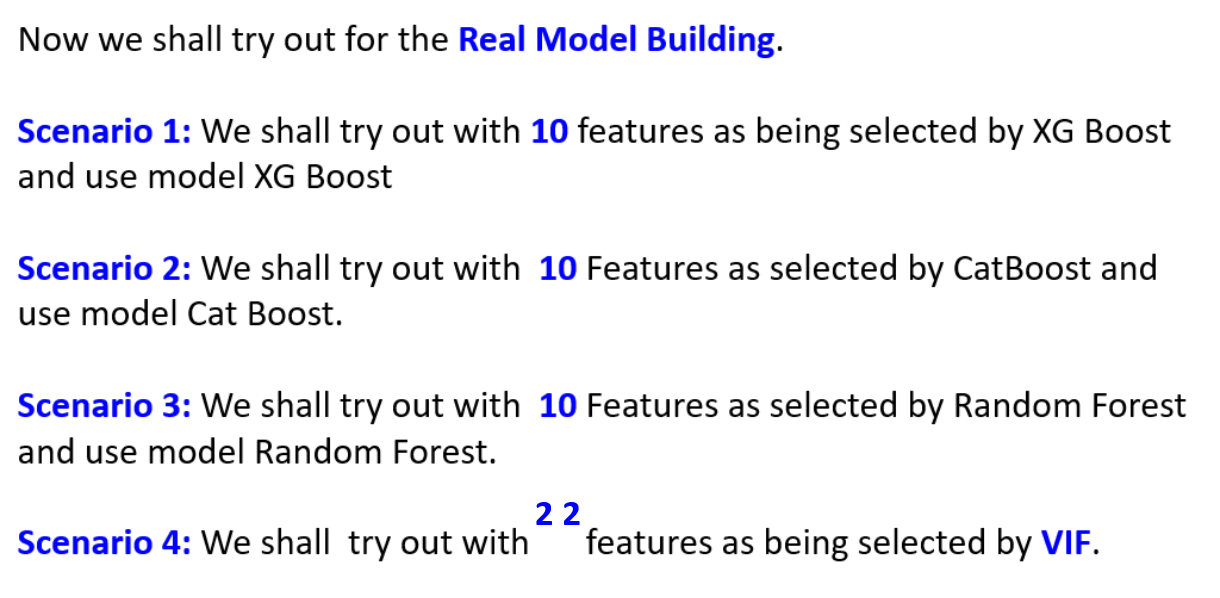

In [96]:
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score

confusion_matrices = {}
classification_reports = {}

**SCENARIO 1:** *XGBoost* **+** *ADASYN* **+** *GridSearchCV* **+** *Threshold Tuning*

In [97]:
# 5) Define XGBClassifierfrom sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import GridSearchCV

# -----------------------------
# 1) Feature selection
# -----------------------------
selected_features = [
    "Employee Job Role_Encoded",
    "Years with Current Manager",
    "Years_Since_Last_Promotion",
    "Experience_Years_In Current Role",
    "Employee Environment Satisfaction",
    "Employee Department_Development",
    "Training_Times_Last_Year",
    "Educational Background_Other",
    "Educational Background_Marketing",
    "Educational Background_Technical Degree"
]

X = data[selected_features]
y = data["Performance Rating"]

# -----------------------------
# 2) Encode target labels
# -----------------------------
# Map {2,3,4} → {0,1,2}
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Store mapping
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class mapping:", class_mapping)
# Example: {2:0, 3:1, 4:2}

# -----------------------------
# 3) Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# -----------------------------
# 4) Apply ADASYN to training data
# -----------------------------
ada = ADASYN(random_state=42)
X_train_res, y_train_res = ada.fit_resample(X_train, y_train)

print("Before ADASYN:", np.bincount(y_train))
print("After ADASYN:", np.bincount(y_train_res))

# -----------------------------
# -----------------------------
xgb = XGBClassifier(
    objective="multi:softprob",  # IMPORTANT: we want probabilities
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# 6) Define parameter grid
# -----------------------------
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "reg_lambda": [1, 5, 10]
}

# -----------------------------
# 7) Custom scorer: F1 for class 4 only
# -----------------------------
# Since 4 → 2 after encoding
f1_class4 = make_scorer(f1_score, labels=[2], average="macro", zero_division=0)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring=f1_class4,
    cv=3,
    verbose=2,
    n_jobs=-1
)

# -----------------------------
# 8) Fit model on resampled data
# -----------------------------
grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 (Class 4 only):", grid.best_score_)

# -----------------------------
# 9) Threshold tuning
# -----------------------------
best_model = grid.best_estimator_

# Predict probabilities
y_proba = best_model.predict_proba(X_test)

# Search thresholds for class 4 (label=2)
thr_vals = np.linspace(0.2, 0.6, 9)
best_f1 = -1
best_thr = 0.5
best_pred = None

for thr in thr_vals:
    y_pred_adj = np.argmax(y_proba, axis=1)  # start with argmax
    # Force class 4 if its prob exceeds threshold
    y_pred_adj[y_proba[:, 2] > thr] = 2

    f1_c4 = f1_score(y_test, y_pred_adj, labels=[2], average="macro", zero_division=0)

    if f1_c4 > best_f1:
        best_f1 = f1_c4
        best_thr = thr
        best_pred = y_pred_adj

print(f"Best threshold for Class 4 = {best_thr:.2f}, F1(class 4) = {best_f1:.3f}")

# -----------------------------
# 10) Final evaluation
# -----------------------------
# Map predictions back to {2,3,4}
y_pred_orig = le.inverse_transform(best_pred)
y_test_orig = le.inverse_transform(y_test)


print("\nClassification Report (All Classes):")
print(classification_report(y_test_orig, y_pred_orig, digits=3))

print("Confusion Matrix (rows = true, cols = predicted):")
print(confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4]))

cm = confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4])
confusion_matrices["Scenario 1: XGBoost + ADASYN"] = cm

cr = classification_report(y_test_orig, y_pred_orig, digits=3)
classification_reports["Scenario 1: XGBoost + ADASYN"] = cr

y_test_orig_sc1 = y_test_orig
y_pred_orig_sc1 = y_pred_orig



Class mapping: {np.int64(2): np.int64(0), np.int64(3): np.int64(1), np.int64(4): np.int64(2)}
Before ADASYN: [155 699 106]
After ADASYN: [717 699 672]
Fitting 3 folds for each of 486 candidates, totalling 1458 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 1.0}
Best CV F1 (Class 4 only): 0.8106600115206385
Best threshold for Class 4 = 0.45, F1(class 4) = 0.280

Classification Report (All Classes):
              precision    recall  f1-score   support

           2      0.886     0.795     0.838        39
           3      0.856     0.886     0.871       175
           4      0.292     0.269     0.280        26

    accuracy                          0.804       240
   macro avg      0.678     0.650     0.663       240
weighted avg      0.800     0.804     0.801       240

Confusion Matrix (rows = true, cols = predicted):
[[ 31   7   1]
 [  4 155  16]
 [  0  19   7]]


**Scenario 2:** *CatBoost* **+** *ADASYN* **+** *GridSearchCV* **+** *Threshold Tuning*

In [98]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, make_scorer
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from imblearn.over_sampling import ADASYN

# -----------------------------
# 1) Feature selection
# -----------------------------
selected_features = [
    "Employee Job Role_Encoded",
    "Years with Current Manager",
    "Years_Since_Last_Promotion",
    "Experience_Years_In Current Role",
    "Employee Environment Satisfaction",
    "Distance From Home",
    "Employee Department_Development",
    "Employee Job Satisfaction",
    "Emp_Relationship_Satisfaction",
    "Num_Companies_Worked"
]

X = data[selected_features]
y = data["Performance Rating"]

# -----------------------------
# 2) Encode target labels
# -----------------------------
le = LabelEncoder()
y_enc = le.fit_transform(y)   # {2,3,4} → {0,1,2}

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class mapping:", class_mapping)
# Example: {2:0, 3:1, 4:2}

# -----------------------------
# 3) Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# -----------------------------
# 4) Apply ADASYN on training data
# -----------------------------
ada = ADASYN(random_state=42)
X_train_res, y_train_res = ada.fit_resample(X_train, y_train)

print("Before ADASYN:", np.bincount(y_train))
print("After ADASYN:", np.bincount(y_train_res))

# -----------------------------
# 5) Define CatBoost model
# -----------------------------
cat = CatBoostClassifier(
    loss_function="MultiClass",
    random_seed=42,
    verbose=False,
    eval_metric="TotalF1"  # still outputs per-class probabilities
)

# -----------------------------
# 6) Parameter grid
# -----------------------------
param_grid = {
    "iterations": [300, 500],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "l2_leaf_reg": [3, 5, 7]
}

# -----------------------------
# 7) Custom scorer: F1 for class 4 only
# -----------------------------
f1_class4 = make_scorer(f1_score, labels=[2], average="macro", zero_division=0)

grid = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    scoring=f1_class4,
    cv=3,
    verbose=2,
    n_jobs=-1
)

# -----------------------------
# 8) Fit model on resampled data
# -----------------------------
grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 (Class 4 only):", grid.best_score_)

# -----------------------------
# 9) Threshold tuning for Class 4
# -----------------------------
best_model = grid.best_estimator_

# Get predicted probabilities
y_proba = best_model.predict_proba(X_test)

thr_vals = np.linspace(0.2, 0.6, 9)  # try different cutoffs
best_f1, best_thr, best_pred = -1, 0.5, None

for thr in thr_vals:
    y_pred_adj = np.argmax(y_proba, axis=1)  # default argmax
    # Force class 4 if its probability > thr
    y_pred_adj[y_proba[:, 2] > thr] = 2

    f1_c4 = f1_score(y_test, y_pred_adj, labels=[2], average="macro", zero_division=0)
    if f1_c4 > best_f1:
        best_f1, best_thr, best_pred = f1_c4, thr, y_pred_adj

print(f"Best threshold for Class 4 = {best_thr:.2f}, F1(class 4) = {best_f1:.3f}")

# -----------------------------
# 10) Final evaluation
# -----------------------------
y_pred_orig = le.inverse_transform(best_pred)
y_test_orig = le.inverse_transform(y_test)

print("\nClassification Report (All Classes):")
print(classification_report(y_test_orig, y_pred_orig, digits=3))

print("Confusion Matrix (rows = true, cols = predicted):")
print(confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4]))

cm = confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4])
confusion_matrices["Scenario 2: CatBoost + ADASYN"] = cm

cr = classification_report(y_test_orig, y_pred_orig, digits=3)
classification_reports["Scenario 2: CatBoost + ADASYN"] = cr

y_test_orig_sc2 = y_test_orig
y_pred_orig_sc2 = y_pred_orig


Class mapping: {np.int64(2): np.int64(0), np.int64(3): np.int64(1), np.int64(4): np.int64(2)}
Before ADASYN: [155 699 106]
After ADASYN: [700 699 682]
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'depth': 8, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Best CV F1 (Class 4 only): 0.8415397055207553
Best threshold for Class 4 = 0.25, F1(class 4) = 0.225

Classification Report (All Classes):
              precision    recall  f1-score   support

           2      0.889     0.821     0.853        39
           3      0.855     0.777     0.814       175
           4      0.178     0.308     0.225        26

    accuracy                          0.733       240
   macro avg      0.641     0.635     0.631       240
weighted avg      0.787     0.733     0.757       240

Confusion Matrix (rows = true, cols = predicted):
[[ 32   6   1]
 [  3 136  36]
 [  1  17   8]]


**SCENARIO 3:** *Random Forest* **+** *ADASYN* **+** *Grid Search* **+** *Threshold Tuning*

In [99]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, make_scorer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import ADASYN

# -----------------------------
# 1) Feature selection
# -----------------------------
selected_features = [
    "Employee Job Role_Encoded",
    "Years with Current Manager",
    "Years_Since_Last_Promotion",
    "Experience_Years_In Current Role",
    "Employee Environment Satisfaction",
    "Distance From Home",
    "Employee Job Satisfaction",
    "Training_Times_Last_Year",
    "Emp_Relationship_Satisfaction",
    "Num_Companies_Worked"
]

X = data[selected_features]
y = data["Performance Rating"]

# -----------------------------
# 2) Encode target labels
# -----------------------------
# Map {2,3,4} → {0,1,2}
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Store mapping
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class mapping:", class_mapping)
# Example: {2:0, 3:1, 4:2}

# -----------------------------
# 3) Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# -----------------------------
# 4) Apply ADASYN on training set
# -----------------------------
ada = ADASYN(random_state=42)
X_train_res, y_train_res = ada.fit_resample(X_train, y_train)

print("Before ADASYN:", np.bincount(y_train))
print("After ADASYN:", np.bincount(y_train_res))

# -----------------------------
# 5) Define Random Forest model
# -----------------------------
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# -----------------------------
# 6) Parameter grid
# -----------------------------
param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# -----------------------------
# 7) Custom scorer for Class 4 F1
# -----------------------------
# Since class 4 is mapped to label 2
f1_class4 = make_scorer(f1_score, labels=[2], average="macro", zero_division=0)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=f1_class4,
    cv=3,
    verbose=2,
    n_jobs=-1
)

# -----------------------------
# 8) Fit model on resampled data
# -----------------------------
grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 (Class 4 only):", grid.best_score_)

# -----------------------------
# 9) Threshold tuning for Class 4
# -----------------------------
best_model = grid.best_estimator_
y_proba = best_model.predict_proba(X_test)

thr_vals = np.linspace(0.2, 0.6, 9)  # candidate thresholds
best_f1, best_thr, best_pred = -1, 0.5, None

for thr in thr_vals:
    y_pred_adj = np.argmax(y_proba, axis=1)  # start with argmax rule
    # Force class 4 if prob > thr
    y_pred_adj[y_proba[:, 2] > thr] = 2

    f1_c4 = f1_score(y_test, y_pred_adj, labels=[2], average="macro", zero_division=0)
    if f1_c4 > best_f1:
        best_f1, best_thr, best_pred = f1_c4, thr, y_pred_adj

print(f"Best threshold for Class 4 = {best_thr:.2f}, F1(class 4) = {best_f1:.3f}")

# -----------------------------
# 10) Final evaluation
# -----------------------------
y_pred_orig = le.inverse_transform(best_pred)
y_test_orig = le.inverse_transform(y_test)

print("\nClassification Report (All Classes):")
print(classification_report(y_test_orig, y_pred_orig, digits=3))

print("Confusion Matrix (rows = true, cols = predicted):")
print(confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4]))

cm = confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4])
confusion_matrices["Scenario 3: Random_Forest + ADASYN"] = cm

cr = classification_report(y_test_orig, y_pred_orig, digits=3)
classification_reports["Scenario 3: Random_Forest + ADASYN"] = cr

y_test_orig_sc3 = y_test_orig
y_pred_orig_sc3 = y_pred_orig


Class mapping: {np.int64(2): np.int64(0), np.int64(3): np.int64(1), np.int64(4): np.int64(2)}
Before ADASYN: [155 699 106]
After ADASYN: [671 699 685]
Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV F1 (Class 4 only): 0.8436355907890075
Best threshold for Class 4 = 0.25, F1(class 4) = 0.267

Classification Report (All Classes):
              precision    recall  f1-score   support

           2      0.842     0.821     0.831        39
           3      0.861     0.531     0.657       175
           4      0.170     0.615     0.267        26

    accuracy                          0.588       240
   macro avg      0.624     0.656     0.585       240
weighted avg      0.783     0.588     0.643       240

Confusion Matrix (rows = true, cols = predicted):
[[32  5  2]
 [ 6 93 76]
 [ 0 10 16]]


**SCENARIO 4:**

The **23** features as was selected by **VIF** are being presented below.

**selected_features** = [
    "Emp_Relationship_Satisfaction",
    "Employee Environment Satisfaction",
    "Employee Job Satisfaction",
    "Business_Travel_Frequency_encoded",
    "Experience_Years_In Current Role",
    "Training_Times_Last_Year",
    "Years with Current Manager",
    "Employee Job Role_Encoded",
    "Marital Status_Married",
    "Employee Department_Research & Development",
    "Marital Status_Single",
    "Employee Department_Development",
    "Distance From Home",
    "Num_Companies_Worked",
    "Years_Since_Last_Promotion",
    "Gender",
    "Educational Background_Marketing",
    "Overtime",
    "Employee Department_Human Resources",
    "Employee Department_Finance",
    "Educational Background_Technical Degree",
    "Educational Background_Other",
    "Performance Rating"
]

**Model:** XGBoost + ADASYN + Grid Search + Threshold Tuning

In [100]:
# 5) Define XGBClassifierfrom sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import ADASYN

# -----------------------------
# 1) Feature selection
# -----------------------------
selected_features = [
    "Emp_Relationship_Satisfaction",
    "Employee Environment Satisfaction",
    "Employee Job Satisfaction",
    "Business_Travel_Frequency_encoded",
    "Experience_Years_In Current Role",
    "Training_Times_Last_Year",
    "Years with Current Manager",
    "Employee Job Role_Encoded",
    "Marital Status_Married",
    "Employee Department_Research & Development",
    "Marital Status_Single",
    "Employee Department_Development",
    "Distance From Home",
    "Num_Companies_Worked",
    "Years_Since_Last_Promotion",
    "Gender",
    "Educational Background_Marketing",
    "Overtime",
    "Employee Department_Human Resources",
    "Employee Department_Finance",
    "Educational Background_Technical Degree",
    "Educational Background_Other",

]

X = data[selected_features]
y = data["Performance Rating"]

# -----------------------------
# 2) Encode target labels
# -----------------------------
# Map {2,3,4} → {0,1,2}
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Store mapping
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class mapping:", class_mapping)
# Example: {2:0, 3:1, 4:2}

# -----------------------------
# 3) Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# -----------------------------
# 4) Apply ADASYN to training data
# -----------------------------
ada = ADASYN(random_state=42)
X_train_res, y_train_res = ada.fit_resample(X_train, y_train)

print("Before ADASYN:", np.bincount(y_train))
print("After ADASYN:", np.bincount(y_train_res))

# -----------------------------
# -----------------------------
xgb = XGBClassifier(
    objective="multi:softprob",  # IMPORTANT: we want probabilities
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# 6) Define parameter grid
# -----------------------------
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "reg_lambda": [1, 5, 10]
}

# -----------------------------
# 7) Custom scorer: F1 for class 4 only
# -----------------------------
# Since 4 → 2 after encoding
f1_class4 = make_scorer(f1_score, labels=[2], average="macro", zero_division=0)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring=f1_class4,
    cv=3,
    verbose=2,
    n_jobs=-1
)

# -----------------------------
# 8) Fit model on resampled data
# -----------------------------
grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 (Class 4 only):", grid.best_score_)

# -----------------------------
# 9) Threshold tuning
# -----------------------------
best_model = grid.best_estimator_

# Predict probabilities
y_proba = best_model.predict_proba(X_test)

# Search thresholds for class 4 (label=2)
thr_vals = np.linspace(0.2, 0.6, 9)
best_f1 = -1
best_thr = 0.5
best_pred = None

for thr in thr_vals:
    y_pred_adj = np.argmax(y_proba, axis=1)  # start with argmax
    # Force class 4 if its prob exceeds threshold
    y_pred_adj[y_proba[:, 2] > thr] = 2

    f1_c4 = f1_score(y_test, y_pred_adj, labels=[2], average="macro", zero_division=0)

    if f1_c4 > best_f1:
        best_f1 = f1_c4
        best_thr = thr
        best_pred = y_pred_adj

print(f"Best threshold for Class 4 = {best_thr:.2f}, F1(class 4) = {best_f1:.3f}")

# -----------------------------
# 10) Final evaluation
# -----------------------------
# Map predictions back to {2,3,4}
y_pred_orig = le.inverse_transform(best_pred)
y_test_orig = le.inverse_transform(y_test)

print("\nClassification Report (All Classes):")
print(classification_report(y_test_orig, y_pred_orig, digits=3))

print("Confusion Matrix (rows = true, cols = predicted):")
print(confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4]))

cm = confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4])
confusion_matrices["Scenario 4A: XGBoost (VIF)"] = cm

cr = classification_report(y_test_orig, y_pred_orig, digits=3)
classification_reports["Scenario 4A: XGBoost (VIF)"] = cr


y_test_orig_sc1_4a = y_test_orig
y_pred_orig_sc1_4a = y_pred_orig


Class mapping: {np.int64(2): np.int64(0), np.int64(3): np.int64(1), np.int64(4): np.int64(2)}
Before ADASYN: [155 699 106]
After ADASYN: [676 699 685]
Fitting 3 folds for each of 486 candidates, totalling 1458 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400, 'reg_lambda': 1, 'subsample': 0.9}
Best CV F1 (Class 4 only): 0.8574522351061571
Best threshold for Class 4 = 0.20, F1(class 4) = 0.264

Classification Report (All Classes):
              precision    recall  f1-score   support

           2      0.900     0.692     0.783        39
           3      0.836     0.874     0.855       175
           4      0.259     0.269     0.264        26

    accuracy                          0.779       240
   macro avg      0.665     0.612     0.634       240
weighted avg      0.784     0.779     0.779       240

Confusion Matrix (rows = true, cols = predicted):
[[ 27  11   1]
 [  3 153  19]
 [  0  19   7]]


**Model:** CatBoost + ADASYN + GridSearchCV + Threshold Tuning

In [101]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, make_scorer
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from imblearn.over_sampling import ADASYN

# -----------------------------
# 1) Feature selection
# -----------------------------
selected_features = [
      "Emp_Relationship_Satisfaction",
    "Employee Environment Satisfaction",
    "Employee Job Satisfaction",
    "Business_Travel_Frequency_encoded",
    "Experience_Years_In Current Role",
    "Training_Times_Last_Year",
    "Years with Current Manager",
    "Employee Job Role_Encoded",
    "Marital Status_Married",
    "Employee Department_Research & Development",
    "Marital Status_Single",
    "Employee Department_Development",
    "Distance From Home",
    "Num_Companies_Worked",
    "Years_Since_Last_Promotion",
    "Gender",
    "Educational Background_Marketing",
    "Overtime",
    "Employee Department_Human Resources",
    "Employee Department_Finance",
    "Educational Background_Technical Degree",
    "Educational Background_Other",
    ]

X = data[selected_features]
y = data["Performance Rating"]

# -----------------------------
# 2) Encode target labels
# -----------------------------
le = LabelEncoder()
y_enc = le.fit_transform(y)   # {2,3,4} → {0,1,2}

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class mapping:", class_mapping)
# Example: {2:0, 3:1, 4:2}

# -----------------------------
# 3) Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# -----------------------------
# 4) Apply ADASYN on training data
# -----------------------------
ada = ADASYN(random_state=42)
X_train_res, y_train_res = ada.fit_resample(X_train, y_train)

print("Before ADASYN:", np.bincount(y_train))
print("After ADASYN:", np.bincount(y_train_res))

# -----------------------------
# 5) Define CatBoost model
# -----------------------------
cat = CatBoostClassifier(
    loss_function="MultiClass",
    random_seed=42,
    verbose=False,
    eval_metric="TotalF1"  # still outputs per-class probabilities
)

# -----------------------------
# 6) Parameter grid
# -----------------------------
param_grid = {
    "iterations": [300, 500],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "l2_leaf_reg": [3, 5, 7]
}

# -----------------------------
# 7) Custom scorer: F1 for class 4 only
# -----------------------------
f1_class4 = make_scorer(f1_score, labels=[2], average="macro", zero_division=0)

grid = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    scoring=f1_class4,
    cv=3,
    verbose=2,
    n_jobs=-1
)

# -----------------------------
# 8) Fit model on resampled data
# -----------------------------
grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 (Class 4 only):", grid.best_score_)

# -----------------------------
# 9) Threshold tuning for Class 4
# -----------------------------
best_model = grid.best_estimator_

# Get predicted probabilities
y_proba = best_model.predict_proba(X_test)

thr_vals = np.linspace(0.2, 0.6, 9)  # try different cutoffs
best_f1, best_thr, best_pred = -1, 0.5, None

for thr in thr_vals:
    y_pred_adj = np.argmax(y_proba, axis=1)  # default argmax
    # Force class 4 if its probability > thr
    y_pred_adj[y_proba[:, 2] > thr] = 2

    f1_c4 = f1_score(y_test, y_pred_adj, labels=[2], average="macro", zero_division=0)
    if f1_c4 > best_f1:
        best_f1, best_thr, best_pred = f1_c4, thr, y_pred_adj

print(f"Best threshold for Class 4 = {best_thr:.2f}, F1(class 4) = {best_f1:.3f}")

# -----------------------------
# 10) Final evaluation
# -----------------------------
y_pred_orig = le.inverse_transform(best_pred)
y_test_orig = le.inverse_transform(y_test)

print("\nClassification Report (All Classes):")
print(classification_report(y_test_orig, y_pred_orig, digits=3))

print("Confusion Matrix (rows = true, cols = predicted):")
print(confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4]))

cm = confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4])
confusion_matrices["Scenario 4B: CatBoost (VIF)"] = cm

cr = classification_report(y_test_orig, y_pred_orig, digits=3)
classification_reports["Scenario 4B: CatBoost (VIF)"] = cr

y_test_orig_sc1_4b = y_test_orig
y_pred_orig_sc1_4b = y_pred_orig


Class mapping: {np.int64(2): np.int64(0), np.int64(3): np.int64(1), np.int64(4): np.int64(2)}
Before ADASYN: [155 699 106]
After ADASYN: [676 699 685]
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'depth': 8, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Best CV F1 (Class 4 only): 0.850310908960432
Best threshold for Class 4 = 0.20, F1(class 4) = 0.286

Classification Report (All Classes):
              precision    recall  f1-score   support

           2      0.886     0.795     0.838        39
           3      0.863     0.829     0.845       175
           4      0.243     0.346     0.286        26

    accuracy                          0.771       240
   macro avg      0.664     0.657     0.656       240
weighted avg      0.800     0.771     0.784       240

Confusion Matrix (rows = true, cols = predicted):
[[ 31   7   1]
 [  3 145  27]
 [  1  16   9]]


**Model:** *Random Forest* **+** *ADASYN* **+** *Grid Search* **+** *Threshold Tuning*

In [102]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, make_scorer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import ADASYN

# -----------------------------
# 1) Feature selection
# -----------------------------
selected_features = [
      "Emp_Relationship_Satisfaction",
    "Employee Environment Satisfaction",
    "Employee Job Satisfaction",
    "Business_Travel_Frequency_encoded",
    "Experience_Years_In Current Role",
    "Training_Times_Last_Year",
    "Years with Current Manager",
    "Employee Job Role_Encoded",
    "Marital Status_Married",
    "Employee Department_Research & Development",
    "Marital Status_Single",
    "Employee Department_Development",
    "Distance From Home",
    "Num_Companies_Worked",
    "Years_Since_Last_Promotion",
    "Gender",
    "Educational Background_Marketing",
    "Overtime",
    "Employee Department_Human Resources",
    "Employee Department_Finance",
    "Educational Background_Technical Degree",
    "Educational Background_Other",
    ]

X = data[selected_features]
y = data["Performance Rating"]

# -----------------------------
# 2) Encode target labels
# -----------------------------
# Map {2,3,4} → {0,1,2}
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Store mapping
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class mapping:", class_mapping)
# Example: {2:0, 3:1, 4:2}

# -----------------------------
# 3) Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# -----------------------------
# 4) Apply ADASYN on training set
# -----------------------------
ada = ADASYN(random_state=42)
X_train_res, y_train_res = ada.fit_resample(X_train, y_train)

print("Before ADASYN:", np.bincount(y_train))
print("After ADASYN:", np.bincount(y_train_res))

# -----------------------------
# 5) Define Random Forest model
# -----------------------------
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# -----------------------------
# 6) Parameter grid
# -----------------------------
param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# -----------------------------
# 7) Custom scorer for Class 4 F1
# -----------------------------
# Since class 4 is mapped to label 2
f1_class4 = make_scorer(f1_score, labels=[2], average="macro", zero_division=0)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=f1_class4,
    cv=3,
    verbose=2,
    n_jobs=-1
)

# -----------------------------
# 8) Fit model on resampled data
# -----------------------------
grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 (Class 4 only):", grid.best_score_)

# -----------------------------
# 9) Threshold tuning for Class 4
# -----------------------------
best_model = grid.best_estimator_
y_proba = best_model.predict_proba(X_test)

thr_vals = np.linspace(0.2, 0.6, 9)  # candidate thresholds
best_f1, best_thr, best_pred = -1, 0.5, None

for thr in thr_vals:
    y_pred_adj = np.argmax(y_proba, axis=1)  # start with argmax rule
    # Force class 4 if prob > thr
    y_pred_adj[y_proba[:, 2] > thr] = 2

    f1_c4 = f1_score(y_test, y_pred_adj, labels=[2], average="macro", zero_division=0)
    if f1_c4 > best_f1:
        best_f1, best_thr, best_pred = f1_c4, thr, y_pred_adj

print(f"Best threshold for Class 4 = {best_thr:.2f}, F1(class 4) = {best_f1:.3f}")

# -----------------------------
# 10) Final evaluation
# -----------------------------
y_pred_orig = le.inverse_transform(best_pred)
y_test_orig = le.inverse_transform(y_test)

print("\nClassification Report (All Classes):")
print(classification_report(y_test_orig, y_pred_orig, digits=3))

print("Confusion Matrix (rows = true, cols = predicted):")
print(confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4]))

cm = confusion_matrix(y_test_orig, y_pred_orig, labels=[2,3,4])
confusion_matrices["Scenario 4C: Random Forest (VIF)"] = cm

cr = classification_report(y_test_orig, y_pred_orig, digits=3)
classification_reports["Scenario 4C: Random Forest (VIF)"] = cr

y_test_orig_sc1_4c = y_test_orig
y_pred_orig_sc1_4c = y_pred_orig


Class mapping: {np.int64(2): np.int64(0), np.int64(3): np.int64(1), np.int64(4): np.int64(2)}
Before ADASYN: [155 699 106]
After ADASYN: [676 699 685]
Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV F1 (Class 4 only): 0.8662676788497868
Best threshold for Class 4 = 0.30, F1(class 4) = 0.300

Classification Report (All Classes):
              precision    recall  f1-score   support

           2      0.917     0.846     0.880        39
           3      0.880     0.754     0.812       175
           4      0.222     0.462     0.300        26

    accuracy                          0.738       240
   macro avg      0.673     0.687     0.664       240
weighted avg      0.815     0.738     0.768       240

Confusion Matrix (rows = true, cols = predicted):
[[ 33   4   2]
 [  3 132  40]
 [  0  14  12]]


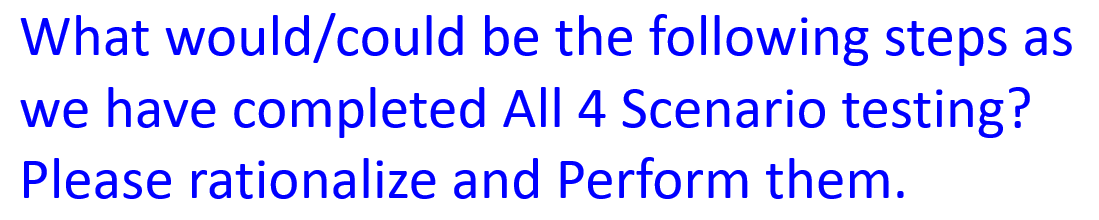

### **BOOTSTRAPPING**

In [103]:
from sklearn.metrics import f1_score

In [104]:
# True labels of the TEST set
y_test = np.array(y_test_orig)

# Predictions from the 6 already-trained models
predictions = {
    "S1_XGB": np.array(y_pred_orig_sc1),
    "S2_CAT": np.array(y_pred_orig_sc2),
    "S3_RF": np.array(y_pred_orig_sc3),
    "S4A_XGB_VIF": np.array(y_pred_orig_sc1_4a),
    "S4B_CAT_VIF": np.array(y_pred_orig_sc1_4b),
    "S4C_RF_VIF": np.array(y_pred_orig_sc1_4c)
}

# Class of interest
positive_class = 4

# Bootstrap parameters
B = 1000
alpha = 0.05
rng = np.random.default_rng(42)

n = len(y_test)


In [105]:
bootstrap_f1 = {}

for model_name, y_pred in predictions.items():

    f1_scores = np.zeros(B)

    for b in range(B):

        # Bootstrap resampling of TEST SET INDICES
        idx = rng.choice(n, size=n, replace=True)

        # Compute F1-score ONLY for Class 4
        f1_scores[b] = f1_score(
            y_test[idx],
            y_pred[idx],
            labels=[positive_class],
            average=None,
            zero_division=0
        )[0]

    bootstrap_f1[model_name] = f1_scores


In [106]:
ranking = []

for model_name, scores in bootstrap_f1.items():
    ranking.append({
        "Model": model_name,
        "Mean F1 (Class 4)": scores.mean(),
        "CI Lower (2.5%)": np.percentile(scores, 2.5),
        "CI Upper (97.5%)": np.percentile(scores, 97.5)
    })

ranking_df = pd.DataFrame(ranking).sort_values(
    "Mean F1 (Class 4)", ascending=False
)

print("\nBOOTSTRAP RANKING (Class 4 F1):")
print(ranking_df)


BOOTSTRAP RANKING (Class 4 F1):
         Model  Mean F1 (Class 4)  CI Lower (2.5%)  CI Upper (97.5%)
5   S4C_RF_VIF           0.299596         0.159091          0.430380
4  S4B_CAT_VIF           0.284580         0.142857          0.425031
0       S1_XGB           0.274406         0.111111          0.436364
2        S3_RF           0.267176         0.165383          0.375000
3  S4A_XGB_VIF           0.265803         0.119941          0.407449
1       S2_CAT           0.224982         0.101653          0.356189


Compare the best-performing candidate against others.

**Research question:** Is my best candidate actually better?

In [107]:
reference_model = ranking_df.iloc[0]["Model"]
pairwise_results = []

for model_name, scores in bootstrap_f1.items():

    if model_name == reference_model:
        continue

    diff = bootstrap_f1[reference_model] - scores

    mean_diff = diff.mean()
    ci_low, ci_high = np.percentile(diff, [2.5, 97.5])

    p_value = 2 * min(
        np.mean(diff <= 0),
        np.mean(diff >= 0)
    )

    pairwise_results.append({
        "Comparison": f"{reference_model} vs {model_name}",
        "Mean ΔF1": mean_diff,
        "CI Lower": ci_low,
        "CI Upper": ci_high,
        "p-value": p_value,
        "Significant (α=0.05)": p_value < alpha
    })

pairwise_df = pd.DataFrame(pairwise_results)

print("\nPAIRWISE BOOTSTRAP TEST RESULTS:")
print(pairwise_df)



PAIRWISE BOOTSTRAP TEST RESULTS:
                  Comparison  Mean ΔF1  CI Lower  CI Upper  p-value  \
0       S4C_RF_VIF vs S1_XGB  0.025189 -0.182342  0.239582    0.828   
1       S4C_RF_VIF vs S2_CAT  0.074613 -0.124373  0.258836    0.430   
2        S4C_RF_VIF vs S3_RF  0.032420 -0.141354  0.201559    0.690   
3  S4C_RF_VIF vs S4A_XGB_VIF  0.033793 -0.183033  0.238218    0.736   
4  S4C_RF_VIF vs S4B_CAT_VIF  0.015016 -0.182269  0.210170    0.876   

   Significant (α=0.05)  
0                 False  
1                 False  
2                 False  
3                 False  
4                 False  


**ACTION:** PRINTING ALL THE CONFUSION MATRICES

In [108]:
for name, cm in confusion_matrices.items():
    print(f"\n{name}")
    print(pd.DataFrame(cm,
                       index=["True_2", "True_3", "True_4"],
                       columns=["Pred_2", "Pred_3", "Pred_4"]))


Scenario 1: XGBoost + ADASYN
        Pred_2  Pred_3  Pred_4
True_2      31       7       1
True_3       4     155      16
True_4       0      19       7

Scenario 2: CatBoost + ADASYN
        Pred_2  Pred_3  Pred_4
True_2      32       6       1
True_3       3     136      36
True_4       1      17       8

Scenario 3: Random_Forest + ADASYN
        Pred_2  Pred_3  Pred_4
True_2      32       5       2
True_3       6      93      76
True_4       0      10      16

Scenario 4A: XGBoost (VIF)
        Pred_2  Pred_3  Pred_4
True_2      27      11       1
True_3       3     153      19
True_4       0      19       7

Scenario 4B: CatBoost (VIF)
        Pred_2  Pred_3  Pred_4
True_2      31       7       1
True_3       3     145      27
True_4       1      16       9

Scenario 4C: Random Forest (VIF)
        Pred_2  Pred_3  Pred_4
True_2      33       4       2
True_3       3     132      40
True_4       0      14      12


**ACTION:** PRINTING ALL THE CLASSIFICATION REPORTS

In [110]:
for name, report in classification_reports.items():
    print("\n" + name)
    print("-" * len(name))
    print(report)


Scenario 1: XGBoost + ADASYN
----------------------------
              precision    recall  f1-score   support

           2      0.886     0.795     0.838        39
           3      0.856     0.886     0.871       175
           4      0.292     0.269     0.280        26

    accuracy                          0.804       240
   macro avg      0.678     0.650     0.663       240
weighted avg      0.800     0.804     0.801       240


Scenario 2: CatBoost + ADASYN
-----------------------------
              precision    recall  f1-score   support

           2      0.889     0.821     0.853        39
           3      0.855     0.777     0.814       175
           4      0.178     0.308     0.225        26

    accuracy                          0.733       240
   macro avg      0.641     0.635     0.631       240
weighted avg      0.787     0.733     0.757       240


Scenario 3: Random_Forest + ADASYN
----------------------------------
              precision    recall  f1-score   s